# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

# Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

**EXECUTIVE SUMMARY**
The business objective of maximizing inventory profitability will be addressed by treating the vehicle 'price' as a continuous target variable for a supervised machine learning regression task.

We will analyze the historical dataset to develop a robust predictive model that estimates the fair market value of vehicles based on their specific attributes. Furthermore, the project will conduct a feature importance analysis to isolate and quantify the main drivers of price variance. By determining which independent variables (e.g., odometer, age, condition) exert the greatest statistical influence on the target, we will provide the dealership with actionable, data-driven insights to optimize both strategies and vehicle pricing.


**Success Criteria**

1) Predictive Accuracy: The model must be able to estimate a vehicle's price within a reasonable error margin (e.g., ±$1,500 of the actual list price).

2) Explainability: The model must provide a clear ranking of feature importance so the dealership can understand exactly which factors (e.g., mileage vs. year) are the primary value drivers.

3) Actionability: The insights must lead to at least one clear recommendation for the dealership's purchasing or inventory strategy

# Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
import numpy as np
import zipfile

In [126]:
# Openning the zip file
with zipfile.ZipFile('data/vehicles.csv.zip') as z:
    # Since I'm using MacOS I need to specify the file I want inside the zip
    with z.open('vehicles.csv') as f:
        data = pd.read_csv(f)

In [127]:
data.tail()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
426875,7301591192,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,wy
426876,7301591187,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,wy
426877,7301591147,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,wy
426878,7301591140,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,wy
426879,7301591129,wyoming,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,gas,22716.0,clean,other,WBA4J1C58KBM14708,rwd,NaN,coupe,NaN,wy


In [128]:
data.shape

(426880, 18)

In [129]:
data.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [130]:
# Checking for missing values and sorting them from highest to lowest
missing_data = data.isnull().sum().sort_values(ascending=False)

print(missing_data)

size            306361
cylinders       177678
condition       174104
VIN             161042
drive           130567
paint_color     130203
type             92858
manufacturer     17646
title_status      8242
model             5277
odometer          4400
fuel              3013
transmission      2556
year              1205
id                   0
region               0
price                0
state                0
dtype: int64


In [131]:
# Calculating the % of missing data for categories with missing data
print(f"% of missing data for size = {(data['size'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for cylinders = {(data['cylinders'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for condition = {(data['condition'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for VIN = {(data['VIN'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for drive = {(data['drive'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for paint_color = {(data['paint_color'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for type = {(data['type'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for manufacturer = {(data['manufacturer'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for title_status = {(data['title_status'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for model = {(data['model'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for odometer = {(data['odometer'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for fuel = {(data['fuel'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for transmission = {(data['transmission'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for year = {(data['year'].isnull().sum() / data.shape[0]) * 100:.2f}%")

% of missing data for size = 71.77%
% of missing data for cylinders = 41.62%
% of missing data for condition = 40.79%
% of missing data for VIN = 37.73%
% of missing data for drive = 30.59%
% of missing data for paint_color = 30.50%
% of missing data for type = 21.75%
% of missing data for manufacturer = 4.13%
% of missing data for title_status = 1.93%
% of missing data for model = 1.24%
% of missing data for odometer = 1.03%
% of missing data for fuel = 0.71%
% of missing data for transmission = 0.60%
% of missing data for year = 0.28%


In [132]:
# Deleting rows with missing data (< 2% per category)

data = data.dropna(subset=['title_status', 'model', 'odometer', 'fuel', 'transmission', 'year'])

# Checking for missing values and sorting them from highest to lowest
missing_data2 = data.isnull().sum().sort_values(ascending=False)

print(missing_data2)

size            288110
cylinders       169060
condition       162527
VIN             155657
drive           121945
paint_color     118219
type             88729
manufacturer     15990
id                   0
transmission         0
odometer             0
title_status         0
region               0
fuel                 0
model                0
year                 0
price                0
state                0
dtype: int64


In [133]:
# Calculating the % of missing data for categories with missing data
print(f"% of missing data for size = {(data['size'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for cylinders = {(data['cylinders'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for condition = {(data['condition'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for VIN = {(data['VIN'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for drive = {(data['drive'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for paint_color = {(data['paint_color'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for type = {(data['type'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for manufacturer = {(data['manufacturer'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for title_status = {(data['title_status'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for model = {(data['model'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for odometer = {(data['odometer'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for fuel = {(data['fuel'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for transmission = {(data['transmission'].isnull().sum() / data.shape[0]) * 100:.2f}%")
print(f"% of missing data for year = {(data['year'].isnull().sum() / data.shape[0]) * 100:.2f}%")

% of missing data for size = 71.03%
% of missing data for cylinders = 41.68%
% of missing data for condition = 40.07%
% of missing data for VIN = 38.38%
% of missing data for drive = 30.07%
% of missing data for paint_color = 29.15%
% of missing data for type = 21.88%
% of missing data for manufacturer = 3.94%
% of missing data for title_status = 0.00%
% of missing data for model = 0.00%
% of missing data for odometer = 0.00%
% of missing data for fuel = 0.00%
% of missing data for transmission = 0.00%
% of missing data for year = 0.00%


### Addressing the 3.94% of missing values in the "manufacturer" column

In [134]:
# Attempting to fix the 3.94% missing data in column "manufacturer"

# Creating a "Lookup Table" from the rows where we ALREADY know the manufacturer
known_data = data.dropna(subset=['manufacturer', 'model'])
model_to_manuf_map = known_data.groupby('model')['manufacturer'].first().to_dict()

# Fill the missing 'manufacturer' values
data['manufacturer'] = data['manufacturer'].fillna(data['model'].map(model_to_manuf_map))

# Checking how many are still missing (in case a model didn't exist in the known_data)
remaining_missing = data['manufacturer'].isna().sum()
print(f"Missing manufacturers remaining: {remaining_missing}")

Missing manufacturers remaining: 15294


In [135]:
# Calculating the % of missing values
print(f"% of missing data for manufacturer = {(data['manufacturer'].isnull().sum() / data.shape[0]) * 100:.2f}%")

% of missing data for manufacturer = 3.77%


In [136]:
# Checking the most common models that are still missing a manufacturer
missing_manuf = data[data['manufacturer'].isna()]
print(missing_manuf['model'].value_counts().head(20))

model
Scion iM Hatchback 4D               640
smart fortwo Passion Hatchback      168
Genesis G80 3.8 Sedan 4D            163
Freightliner Cascadia               153
International 4300                  141
Scion xD Hatchback 4D               134
Genesis G70 2.0T Sedan 4D           131
Scion xB                            114
HUMMER H2                           112
Scion FR-S Coupe 2D                 112
Genesis G70 3.3T Advanced Sedan     102
Scion tC                            100
Other                                85
hummer h3                            82
Genesis G70 3.3T Dynamic Edition     81
freightliner cascadia                78
International TerraStar              74
Genesis G70 2.0T Advanced Sedan      73
Isuzu NPR                            72
Scion FR-S Release Series 2.0        70
Name: count, dtype: int64


In [137]:
# Normalizing strings to lowercase to catch "HUMMER" and "hummer"
data['model_lower'] = data['model'].str.lower()

# Defining the mapping
pattern_map = {
    'scion': 'Scion',
    'genesis': 'Genesis',
    'freightliner': 'Freightliner',
    'hummer': 'Hummer',
    'international': 'International',
    'isuzu': 'Isuzu',
    'smart': 'smart'
}

# Applying the mapping
for pattern, manufacturer in pattern_map.items():
    mask = (data['manufacturer'].isna()) & (data['model_lower'].str.contains(pattern, na=False))
    data.loc[mask, 'manufacturer'] = manufacturer

# Cleaning up
data = data.drop(columns=['model_lower'])

# Checking remaining missing values
print(f"Remaining missing manufacturers: {data['manufacturer'].isna().sum()}")
# Calculating the % of missing values
print(f"% of missing data for manufacturer = {(data['manufacturer'].isnull().sum() / data.shape[0]) * 100:.2f}%")

Remaining missing manufacturers: 9661
% of missing data for manufacturer = 2.38%


In [138]:
# Isolate the remaining missing
still_missing = data[data['manufacturer'].isna()]

# Biggest offenders
print(still_missing['model'].value_counts().head(50))

model
Other                               85
Maserati Ghibli                     65
Hino 268                            61
saab 9-3                            60
all                                 59
ALL MAKES                           56
peterbilt 579                       55
oldsmobile cutlass                  49
Janesville                          49
PROGRAMS as little as $500 DOWN!    48
WE SAY YES                          48
JUST TOO EASY!                      44
Lamborghini Huracan                 42
BUY HERE PAY HERE                   41
2017                                41
MASERATI GHIBLI                     38
ALL                                 37
2018                                33
ALL MAKES & MODELS                  32
CountryAuto                         31
Flexible Down Payments              30
Polaris Slingshot                   30
chryler town and country            29
plymouth barracuda                  29
Suzuki SX4                          29
Mclaren 570GT W/ Up

In [139]:
# Creating a list of clear marketing noise
noise_list = [
    'buy here pay here', 'we say yes', 'just too easy', 
    'flexible down payments', 'programs as little as', 'all makes', 
    'all makes & models', 'any and all', 'other', 'all'
]

# Creating a mask for rows that are clearly garbage
data['model_lower'] = data['model'].str.lower()
mask_garbage = data['model_lower'].isin(noise_list)

# Drop those rows
print(f"Dropping {mask_garbage.sum()} rows of marketing noise")
data = data[~mask_garbage]

Dropping 479 rows of marketing noise


In [140]:
# Mapping more models to their correct manufacturer
manual_map = {
    'maserati': 'Maserati',
    'saab': 'Saab',
    'suzuki': 'Suzuki',
    'oldsmobile': 'Oldsmobile',
    'freightliner': 'Freightliner',
    'international': 'International',
    'polaris': 'Polaris',
    'hummer': 'Hummer',
    'mclaren': 'McLaren',
    'kenworth': 'Kenworth',
    'peterbilt': 'Peterbilt',
    'blue bird': 'Blue Bird'
}

# Applying the map
for model_key, manufacturer in manual_map.items():
    mask = (data['manufacturer'].isna()) & (data['model_lower'].str.contains(model_key))
    data.loc[mask, 'manufacturer'] = manufacturer

# Dropping rows where the model is just a 4-digit year (e.g., '2017')
mask_years = data['model'].astype(str).str.match(r'^\d{4}$')
data = data[~mask_years]

In [141]:
# One final check
still_missing = data[data['manufacturer'].isna()]

# Biggest offenders
print(still_missing['model'].value_counts().head(50))

model
Hino 268                            61
Janesville                          49
PROGRAMS as little as $500 DOWN!    48
JUST TOO EASY!                      44
Lamborghini Huracan                 42
CountryAuto                         31
chryler town and country            29
plymouth barracuda                  29
Workhorse W42                       27
to 2017                             24
09 HONDS ODYSSEY EXL                24
CHEVORLET EXPRESS 3500 1 TON        21
TOYOTA* YARIS*                      20
sterling acterra                    19
Pierce Model Tilt Cab               19
ROLLS ROYCE PHANTOM                 18
cars and suvs                       18
forde450                            18
PROGRAMS as little as $500!         17
mg mgb                              17
wheelchair handicap van             17
STERLING L                          17
mg midget                           17
ACRUA TL                            16
-2018 Cars and SUV's                16
ALL MAKES AND MODEL

In [142]:
# Calculating the % of missing values
print(f"% of missing data for manufacturer = {(data['manufacturer'].isnull().sum() / data.shape[0]) * 100:.2f}%")

% of missing data for manufacturer = 1.75%


In [143]:
# 1.75% of missing values is now < 2%. Will proceed to drop this data
original_count = len(data)

# Dropping the rows where 'manufacturer' is NaN or None
data = data.dropna(subset=['manufacturer'])

# Checking the count after dropping
final_count = len(data)

print(f"Original row count: {original_count}")
print(f"Final row count: {final_count}")
print(f"Rows removed: {original_count - final_count}")

Original row count: 396113
Final row count: 389176
Rows removed: 6937


In [144]:
# Checking for bad values in all columns
bad_values = ["Unknown", "N/A", "?", "None", "nan"]

data.isin(bad_values).sum()

id              0
region          0
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
VIN             0
drive           0
size            0
type            0
paint_color     0
state           0
model_lower     0
dtype: int64

In [145]:
# Creating a mask that catches null values across ALL of these columns
important_cols = [
    "year", "manufacturer", "model", "condition", "cylinders", 
    "fuel", "odometer", "title_status", "transmission", "VIN", 
    "drive", "size", "type", "paint_color"
]

bad_rows = data[important_cols].isna()

# Checking each rows with missing values across multiple columns
rows_to_drop = bad_rows.all(axis=1)

# Quantify: Sum the True values
count = rows_to_drop.sum()

print(f"Number of rows with ALL missing values: {count}")

Number of rows with ALL missing values: 0


In [146]:
# checking for duplicates
data.duplicated().sum()

np.int64(0)

In [147]:
# Inspecting the duplciates
data[data.duplicated(keep=False)]

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state,model_lower


In [148]:
# Checking the number of records where the value is equal to "0"
zeros = data.eq(0).sum().sort_values(ascending=False)

print(zeros)

price           28385
odometer         1331
title_status        0
state               0
paint_color         0
type                0
size                0
drive               0
VIN                 0
transmission        0
id                  0
region              0
fuel                0
cylinders           0
condition           0
model               0
manufacturer        0
year                0
model_lower         0
dtype: int64


In [149]:
# Calculate the % of value "0" in price and odometer as both are important metrics for the future ML model
print(f"% of rows with value = 0 in price = {(data['price'].eq(0).sum() / data.shape[0]) * 100:.2f}%")
print(f"% of rows with value = 0 in odometer = {(data['odometer'].eq(0).sum() / data.shape[0]) * 100:.2f}%")

% of rows with value = 0 in price = 7.29%
% of rows with value = 0 in odometer = 0.34%


In [150]:
# Dropping the rows with odometer with 0
data = data[data['odometer'] > 0]

# Confirming the rows have been removed
print(f"% of rows with value = 0 in odometer = {(data['odometer'].eq(0).sum() / data.shape[0]) * 100:.2f}%")

% of rows with value = 0 in odometer = 0.00%


### Addressing the 7.29% of cars with Price = 0

A car listed at $0 could simply be a placeholder, however, trying to guess what the price should have been, I wiill be essentially training my model on "fake" data, which is a risks for possible biasing.

However, before deleting 7.29% of the rows, I will make ensure I'm not accidentally deleting all the cars from a specific brand or age group

In [151]:
# Identifying rows with 0 price
zero_price = data[data['price'] == 0]

# Comparing the distribution of manufacturers for zero-price vs. regular-price cars
# If one brand is heavily represented in the zero-price group, then there is biased data
print("Manufacturer distribution in Zero-Price rows:")
print(zero_price['manufacturer'].value_counts(normalize=True).head(10))

print("\nManufacturer distribution in Valid-Price rows:")
print(data[data['price'] > 0]['manufacturer'].value_counts(normalize=True).head(10))

Manufacturer distribution in Zero-Price rows:
manufacturer
ford             0.191051
chevrolet        0.143640
toyota           0.082492
nissan           0.053432
jeep             0.051882
mercedes-benz    0.047159
gmc              0.045573
honda            0.044275
dodge            0.038650
ram              0.034576
Name: proportion, dtype: float64

Manufacturer distribution in Valid-Price rows:
manufacturer
ford             0.172559
chevrolet        0.132701
toyota           0.084436
honda            0.053114
jeep             0.046339
nissan           0.045947
gmc              0.040324
bmw              0.036939
dodge            0.032179
mercedes-benz    0.027417
Name: proportion, dtype: float64


By looking at this data, I decided to follow a pragmatic approach.

I decided to exclude 7.29% of the rows with a price of $0. It was noted that luxury manufacturers (specifically Mercedes-Benz) were slightly over-represented in these excluded rows, suggesting a possible 'Call for Price' marketing strategy rather than data corruption. This exclusion is unlikely to impact model performance for the broader market.

Since this is a large dataset (426K rows), the bias is low impact. 

Since I'm trying to building a model to help the client understand what factors make a car more or less expensive, I need "truth" labels. A car priced at $0 is not truth, including them or trying to estimate them will pollute my training data and could lead to less accurate predictions for the client.

In [152]:
# Ensuring the 'price' column is numeric
data['price'] = pd.to_numeric(data['price'], errors='coerce')

# Counting the rows before dropping
initial_count = len(data)

# Keeping only the rows where price is greater than 0
data = data[data['price'] > 0]

# Final verification
final_count = len(data)
print(f"Original row count: {initial_count}")
print(f"Final row count: {final_count}")
print(f"Rows removed: {initial_count - final_count}")

Original row count: 387845
Final row count: 360109
Rows removed: 27736


In [153]:
# Calculate the % of value "0" in price and odometer as both are important metrics for the future ML model
print(f"% of rows with value = 0 in price = {(data['price'].eq(0).sum() / data.shape[0]) * 100:.2f}%")

% of rows with value = 0 in price = 0.00%


### Checking for UNIQUE values across categorical columns

In [154]:
print(data["manufacturer"].unique())

['gmc' 'chevrolet' 'toyota' 'ford' 'jeep' 'nissan' 'ram' 'mazda'
 'cadillac' 'honda' 'dodge' 'lexus' 'jaguar' 'buick' 'chrysler' 'volvo'
 'audi' 'infiniti' 'lincoln' 'alfa-romeo' 'subaru' 'Scion' 'acura'
 'hyundai' 'mercedes-benz' 'Blue Bird' 'bmw' 'mitsubishi' 'smart'
 'volkswagen' 'porsche' 'kia' 'Maserati' 'Saab' 'Suzuki' 'ferrari' 'mini'
 'pontiac' 'Oldsmobile' 'International' 'fiat' 'rover' 'Genesis' 'Hummer'
 'Isuzu' 'Freightliner' 'Kenworth' 'tesla' 'saturn' 'mercury'
 'harley-davidson' 'Peterbilt' 'datsun' 'McLaren' 'Polaris' 'aston-martin'
 'land rover']


In [155]:
print(data["model"].unique())

['sierra 1500 crew cab slt' 'silverado 1500' 'silverado 1500 crew' ...
 'cj 3a willys' 'rx& gls sport' 'gand wagoneer']


In [156]:
print(data["condition"].unique())

['good' 'excellent' 'fair' 'like new' 'new' nan 'salvage']


In [157]:
print(data["cylinders"].unique())

['8 cylinders' '6 cylinders' nan '4 cylinders' '5 cylinders' '3 cylinders'
 '10 cylinders' 'other' '12 cylinders']


In [158]:
print(data["fuel"].unique())

['gas' 'other' 'diesel' 'hybrid' 'electric']


In [159]:
print(data["title_status"].unique())

['clean' 'rebuilt' 'lien' 'salvage' 'missing' 'parts only']


In [160]:
print(data["transmission"].unique())

['other' 'automatic' 'manual']


In [161]:
print(data["drive"].unique())

[nan 'rwd' '4wd' 'fwd']


In [162]:
print(data["size"].unique())

[nan 'full-size' 'mid-size' 'compact' 'sub-compact']


In [163]:
print(data["type"].unique())

['pickup' 'truck' 'other' nan 'coupe' 'SUV' 'hatchback' 'mini-van' 'sedan'
 'offroad' 'bus' 'convertible' 'wagon' 'van']


In [164]:
print(data["paint_color"].unique())

['white' 'blue' 'red' 'black' 'silver' 'grey' nan 'brown' 'yellow'
 'orange' 'green' 'custom' 'purple']


In [165]:
print(data["state"].unique())

['al' 'ak' 'az' 'ar' 'ca' 'co' 'ct' 'dc' 'de' 'fl' 'ga' 'hi' 'id' 'il'
 'in' 'ia' 'ks' 'ky' 'la' 'me' 'md' 'ma' 'mi' 'mn' 'ms' 'mo' 'mt' 'nc'
 'ne' 'nv' 'nj' 'nm' 'ny' 'nh' 'nd' 'oh' 'ok' 'or' 'pa' 'ri' 'sc' 'sd'
 'tn' 'tx' 'ut' 'vt' 'va' 'wa' 'wv' 'wi' 'wy']


In [166]:
data.shape

(360109, 19)

In [167]:
# Cleanning up the model names column / creating splits with the intention to evaluate if creating additional features is useful to train the ML model

# Creating a copy of the column model and ensure it is clean
model_clean = data['model'].fillna('')

# Convert to string
model_clean = model_clean.astype(str).replace('None', '')

# Split the text
split_data = model_clean.str.split(expand=True)

# Rename columns dynamically based on how many were created
split_data.columns = [f'model_word_{i+1}' for i in range(split_data.shape[1])]

# Ensure the indices match before adding columns back to 'data'
split_data.index = data.index 
data = pd.concat([data, split_data], axis=1)

print("Split complete. New columns added:")
print(data.filter(like='model_word_').head())

Split complete. New columns added:
   model_word_1 model_word_2 model_word_3 model_word_4 model_word_5  \
27       sierra         1500         crew          cab          slt   
28    silverado         1500         None         None         None   
29    silverado         1500         crew         None         None   
30       tundra       double          cab           sr         None   
31        f-150          xlt         None         None         None   

   model_word_6 model_word_7 model_word_8 model_word_9 model_word_10  ...  \
27         None         None         None         None          None  ...   
28         None         None         None         None          None  ...   
29         None         None         None         None          None  ...   
30         None         None         None         None          None  ...   
31         None         None         None         None          None  ...   

   model_word_22 model_word_23 model_word_24 model_word_25 model_word_26  \

In [168]:
# Selecting only the newly created columns
new_model_cols = data.filter(like='model_word_')

# Count the occurrences of the string "None"
none_string_count = (new_model_cols == 'None').sum()

# Count the actual null/NaN values
null_count = new_model_cols.isna().sum()

print("Count of string 'None' per column:")
print(none_string_count)
print("\nCount of actual null/NaN values per column:")
print(null_count)

Count of string 'None' per column:
model_word_1     0
model_word_2     0
model_word_3     0
model_word_4     0
model_word_5     0
model_word_6     0
model_word_7     0
model_word_8     0
model_word_9     0
model_word_10    0
model_word_11    0
model_word_12    0
model_word_13    0
model_word_14    0
model_word_15    0
model_word_16    0
model_word_17    0
model_word_18    0
model_word_19    0
model_word_20    0
model_word_21    0
model_word_22    0
model_word_23    0
model_word_24    0
model_word_25    0
model_word_26    0
model_word_27    0
model_word_28    0
model_word_29    0
model_word_30    0
model_word_31    0
dtype: int64

Count of actual null/NaN values per column:
model_word_1          0
model_word_2     158337
model_word_3     242495
model_word_4     291334
model_word_5     336563
model_word_6     355947
model_word_7     358220
model_word_8     358622
model_word_9     358854
model_word_10    359149
model_word_11    359269
model_word_12    359371
model_word_13    359403
model_

In [169]:
# Keeping only the first 3 columns and cleanning the dataset

# Concatenate the first 3 words into a new temporary column
data['temp_model'] = (
    data['model_word_1'].fillna('') + ' ' + 
    data['model_word_2'].fillna('') + ' ' + 
    data['model_word_3'].fillna('')
).str.strip()

# Identify all the columns we no longer need
cols_to_remove = [col for col in data.columns if 'model_word_' in col]

# Drop the old columns and the original 'model' column
data = data.drop(columns=cols_to_remove + ['model'], errors='ignore')

# Rename 'temp_model' back to 'model'
data = data.rename(columns={'temp_model': 'model'})

# Verification
print(data.head())

            id  region  price    year manufacturer  condition    cylinders  \
27  7316814884  auburn  33590  2014.0          gmc       good  8 cylinders   
28  7316814758  auburn  22590  2010.0    chevrolet       good  8 cylinders   
29  7316814989  auburn  39590  2020.0    chevrolet       good  8 cylinders   
30  7316743432  auburn  30990  2017.0       toyota       good  8 cylinders   
31  7316356412  auburn  15000  2013.0         ford  excellent  6 cylinders   

   fuel  odometer title_status transmission                VIN drive  \
27  gas   57923.0        clean        other  3GTP1VEC4EG551563   NaN   
28  gas   71229.0        clean        other  1GCSCSE06AZ123805   NaN   
29  gas   19160.0        clean        other  3GCPWCED5LG130317   NaN   
30  gas   41124.0        clean        other  5TFRM5F17HX120972   NaN   
31  gas  128000.0        clean    automatic                NaN   rwd   

         size    type paint_color state               model_lower  \
27        NaN  pickup       w

In [170]:
# Drop the 'model_lower' column
data = data.drop(columns=['model_lower'], errors='ignore')

# Verification
data.head()

,id,region,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state,model
27,7316814884,auburn,33590,2014.0,gmc,good,8 cylinders,gas,57923.0,clean,other,3GTP1VEC4EG551563,NaN,NaN,pickup,white,al,sierra 1500 crew
28,7316814758,auburn,22590,2010.0,chevrolet,good,8 cylinders,gas,71229.0,clean,other,1GCSCSE06AZ123805,NaN,NaN,pickup,blue,al,silverado 1500
29,7316814989,auburn,39590,2020.0,chevrolet,good,8 cylinders,gas,19160.0,clean,other,3GCPWCED5LG130317,NaN,NaN,pickup,red,al,silverado 1500 crew
30,7316743432,auburn,30990,2017.0,toyota,good,8 cylinders,gas,41124.0,clean,other,5TFRM5F17HX120972,NaN,NaN,pickup,red,al,tundra double cab
31,7316356412,auburn,15000,2013.0,ford,excellent,6 cylinders,gas,128000.0,clean,automatic,NaN,rwd,full-size,truck,black,al,f-150 xlt


### Feature Visualization

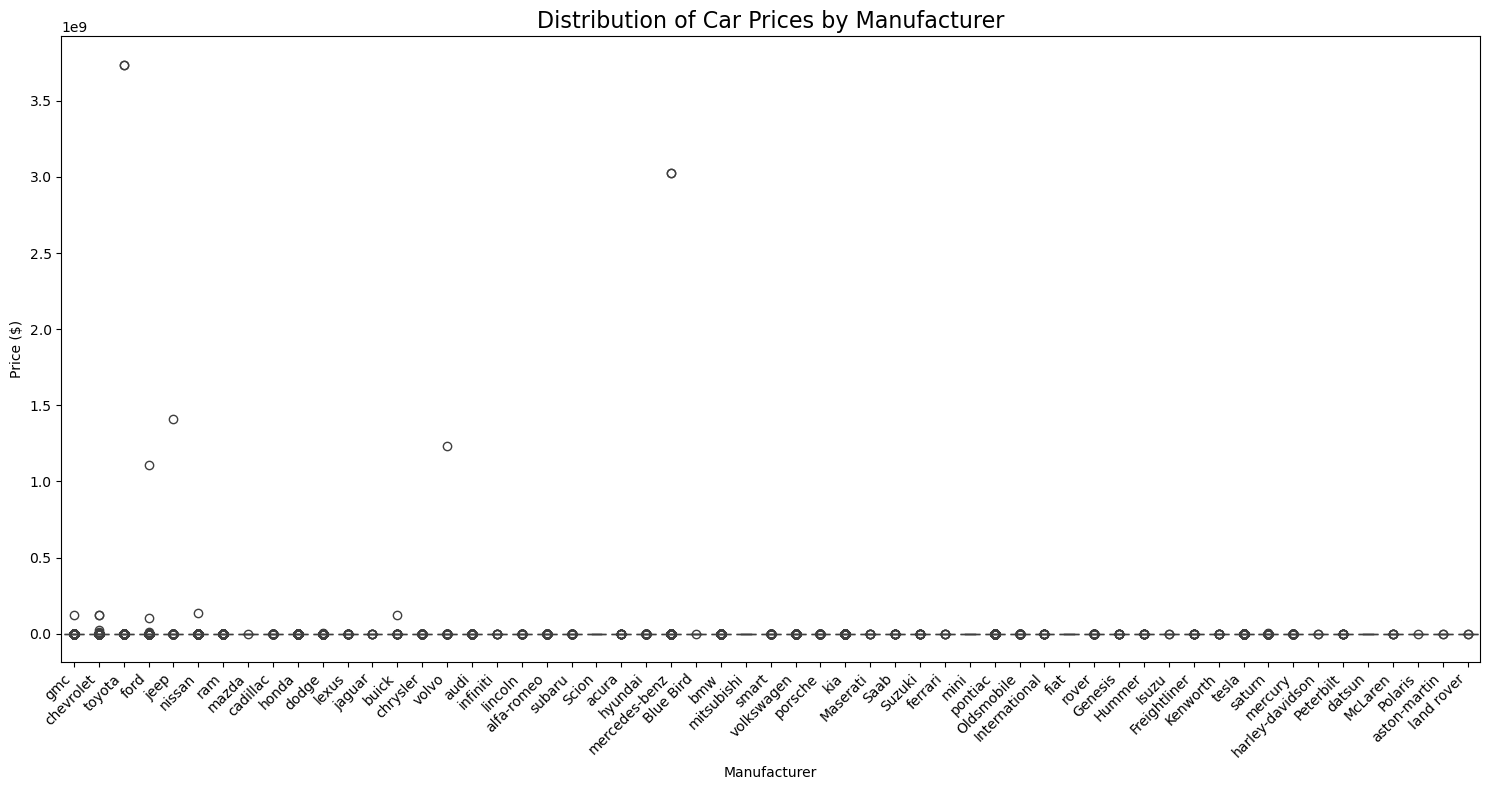

In [171]:
# Checking which models are the outliers

plt.figure(figsize=(15, 8))
# Boxplot
sns.boxplot(x='manufacturer', y='price', data=data)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Car Prices by Manufacturer', fontsize=16)
plt.ylabel('Price ($)')
plt.xlabel('Manufacturer')

plt.tight_layout()
plt.show()
plt.close('all')

In [172]:
# Some of these make no sense. Looking deeper before I remove
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Filtering rows ABOVE the upper bound
outliers = data[data['price'] > upper_bound]

# Selecting only the columns relevant for the assessment
cols = ['manufacturer', 'model', 'year', 'price', 'odometer', 'title_status']

# Sorting by price
detailed_outliers = outliers[cols].sort_values(by='price', ascending=False)

print(detailed_outliers.head(50))

         manufacturer                     model    year       price  \
356716         toyota                   4runner  1999.0  3736928711   
318592         toyota                    tundra  2007.0  3736928711   
257840  mercedes-benz                 benz s430  2000.0  3024942282   
91576   mercedes-benz                 benz e320  2000.0  3024942282   
184704           jeep                  wrangler  1989.0  1410065407   
153082          volvo                       vnl  2006.0  1234567890   
29386            ford           f350 super duty  1999.0  1111111111   
230753         nissan          titan se kingcab  2008.0   135008900   
288356      chevrolet                   project  1965.0   123456789   
137807          buick                     regal  1999.0   123456789   
307488            gmc               sierra 2500  1996.0   123456789   
193736      chevrolet                     cruze  2015.0   123456789   
1838             ford                    ranger  1993.0    99999999   
379133

In [173]:
# It is clear some of these outliers is a systemic data corruption
# Dropping anything over $400,000 immediately as it is likely a system error
data = data[data['price'] <= 400000]

# Manufacturer-Specific realistic maximums
caps = {
    'chrysler': 80000,
    'chevrolet': 100000,
    'ford': 120000,
    'dodge': 80000,
    'gmc': 90000,
    'jeep': 90000,
    'buick': 60000,
    'toyota': 90000,
    'honda': 70000,
    'saturn': 30000,
    'lincoln': 80000
}

# Apply the manufacturer-specific caps
def apply_caps(row):
    manuf = row['manufacturer'].lower()
    price = row['price']
    limit = caps.get(manuf, 150000) # Default to 150k for brands not listed
    return price <= limit

# Filter the data
data = data[data.apply(apply_caps, axis=1)]

print(f"Dataset size after extreme outlier removal: {len(data)}")

Dataset size after extreme outlier removal: 359868


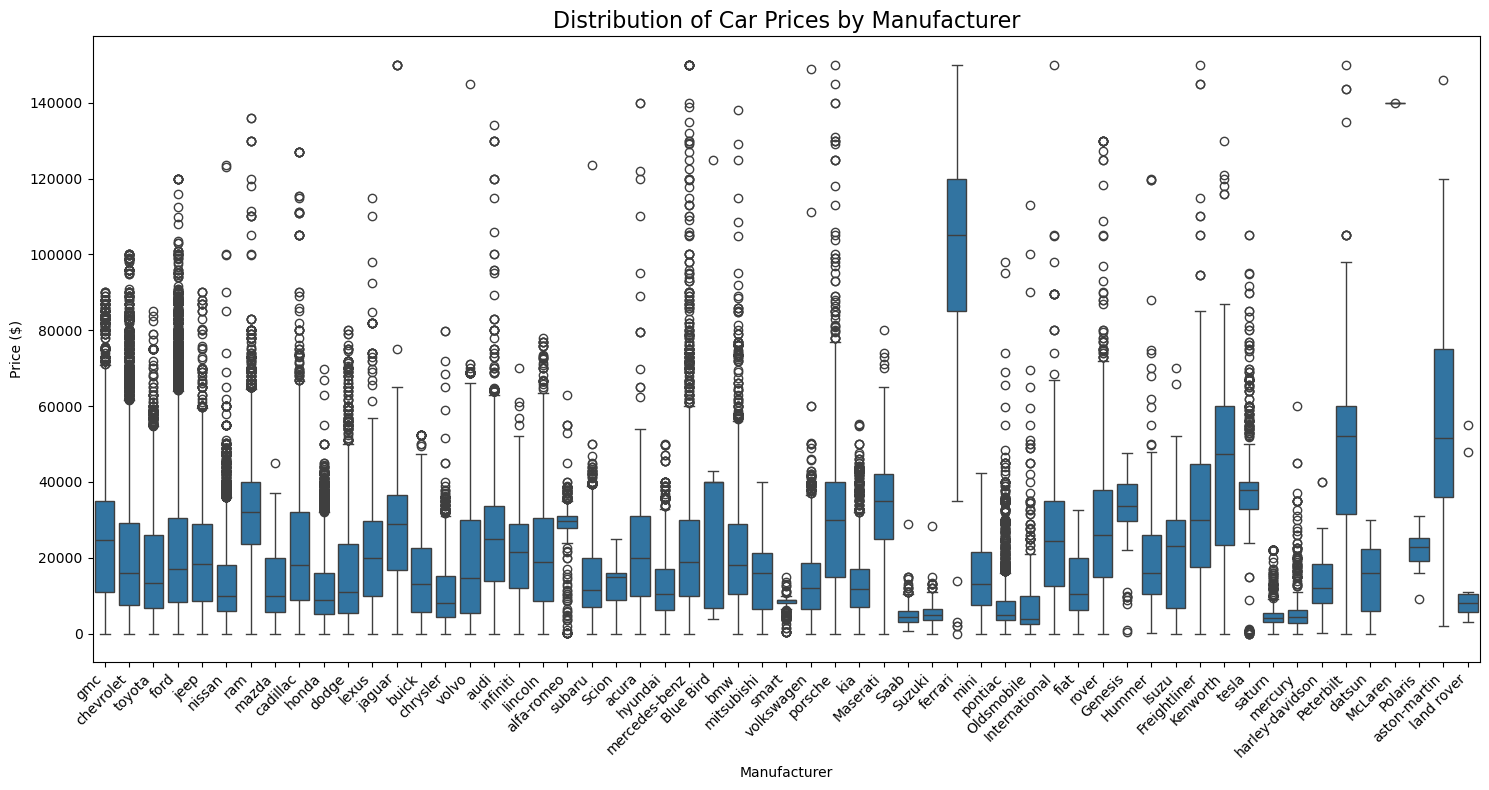

In [174]:
# Checking which models are the outliers

plt.figure(figsize=(15, 8))
# Boxplot
sns.boxplot(x='manufacturer', y='price', data=data)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Car Prices by Manufacturer', fontsize=16)
plt.ylabel('Price ($)')
plt.xlabel('Manufacturer')

plt.tight_layout()
plt.show()
plt.close('all')

### Strategy for the remaining missing data


**Bucket A: Possible "Garbage" - will drop**

% of missing data for size = 71.03% --> missing % is too high to reliably impute. "size" is often correlated with model and type anyway

% of missing data for VIN = 38.38% --> This is an ID, not a feature. It has zero predictive value for price.


**Bucket B: The "Predictive" (Impute) - will keep**

% of missing data for cylinders = 41.68%

% of missing data for drive = 30.07%

% of missing data for type = 21.88%

% of missing data for condition = 40.07%

Even with 20–40% missing, these are normally price drivers. A V8 engine (cylinders) or All-Wheel Drive (drive) significantly changes a car's value. Will try to impute by using the "mode" or by grouping by model and filling the missing values with the most frequent value for that specific car model.


**Bucket C: The "Cosmetic" - will keep for now**

% of missing data for paint_color = 29.15% --> Probably low impact but some colors might have an impact on luxury brands. Will keep for now but for me, this is a low rank for now

Columns before dropping: 18
Columns after dropping: 16
Remaining columns: ['id', 'region', 'price', 'year', 'manufacturer', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state', 'model']


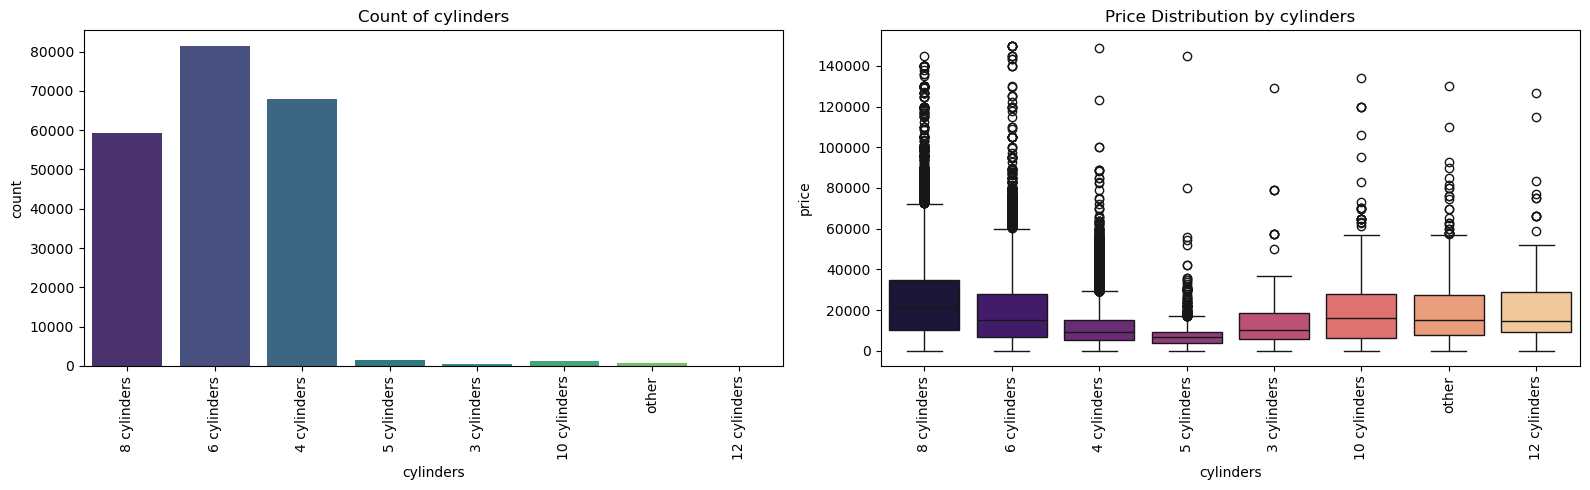

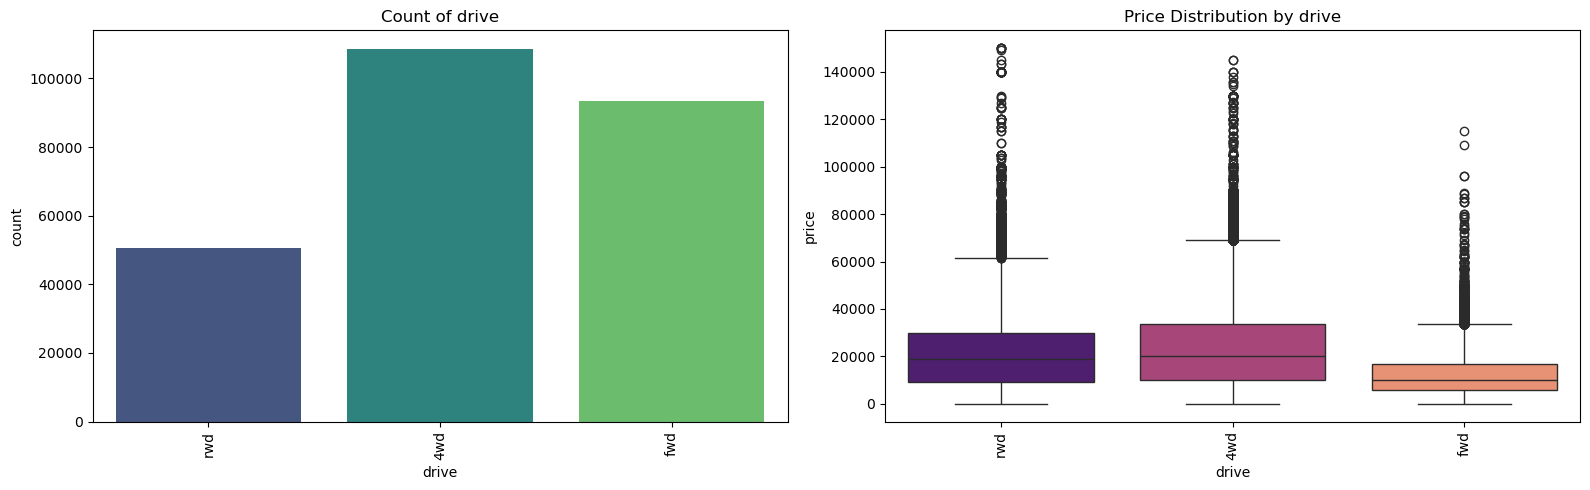

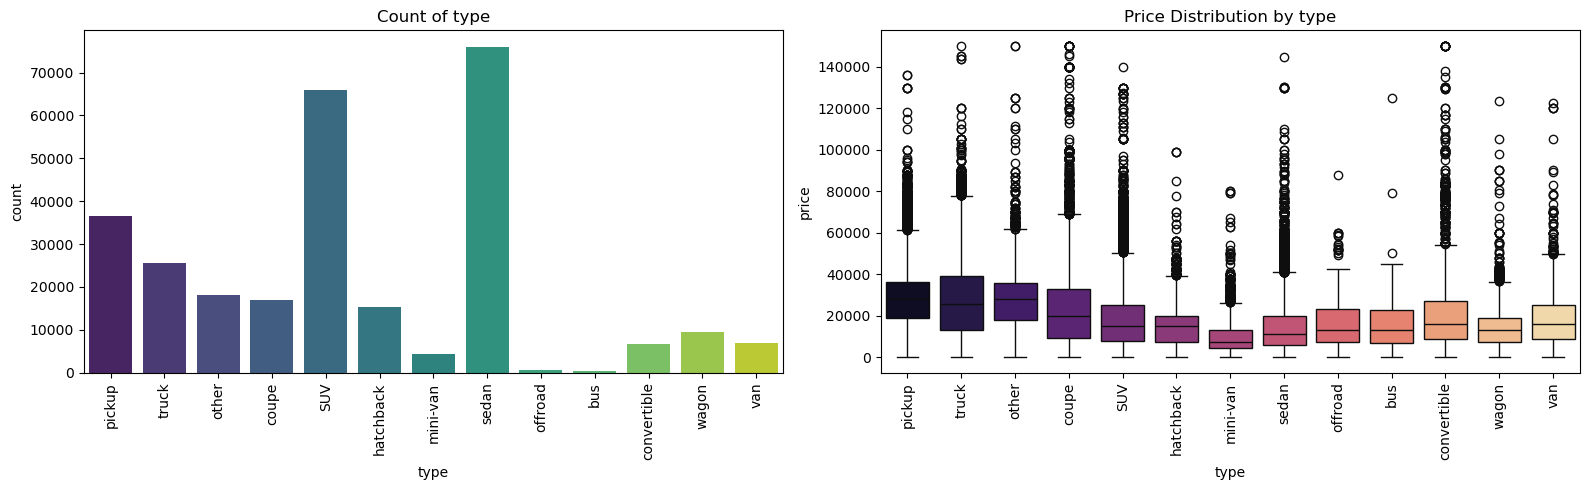

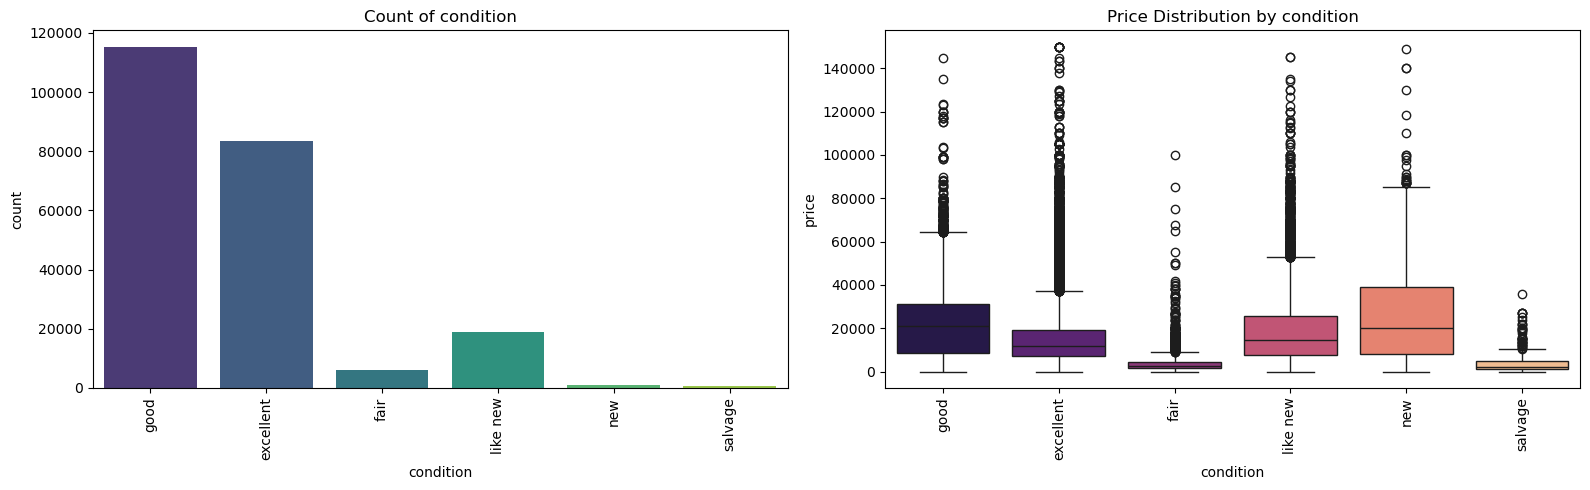

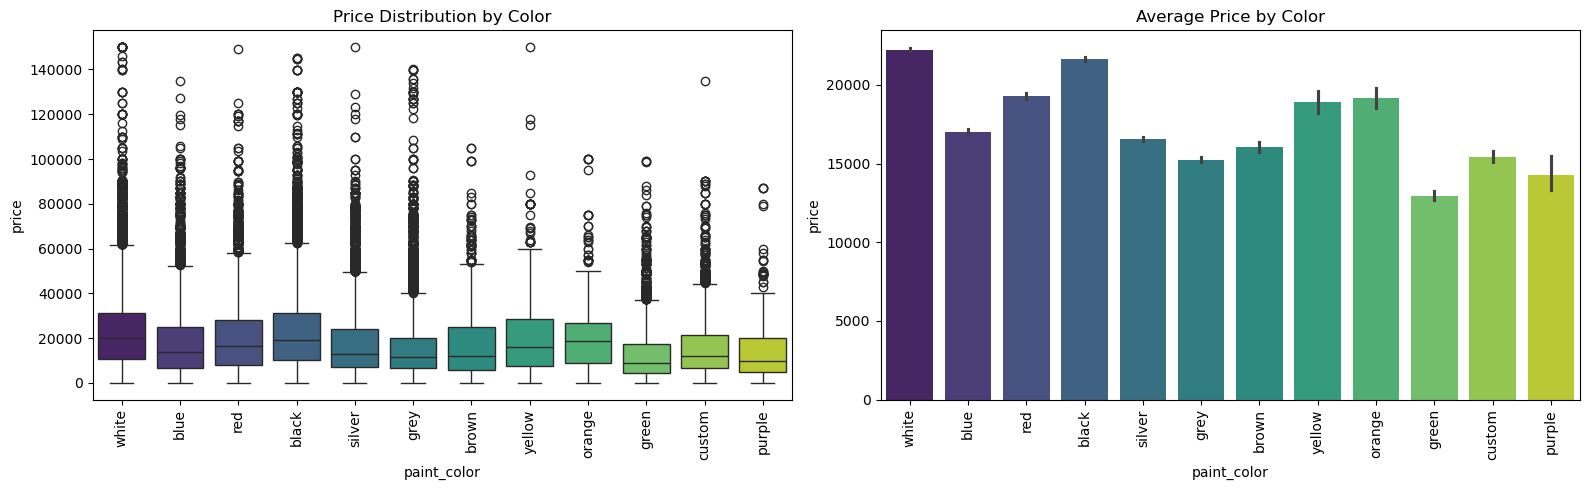

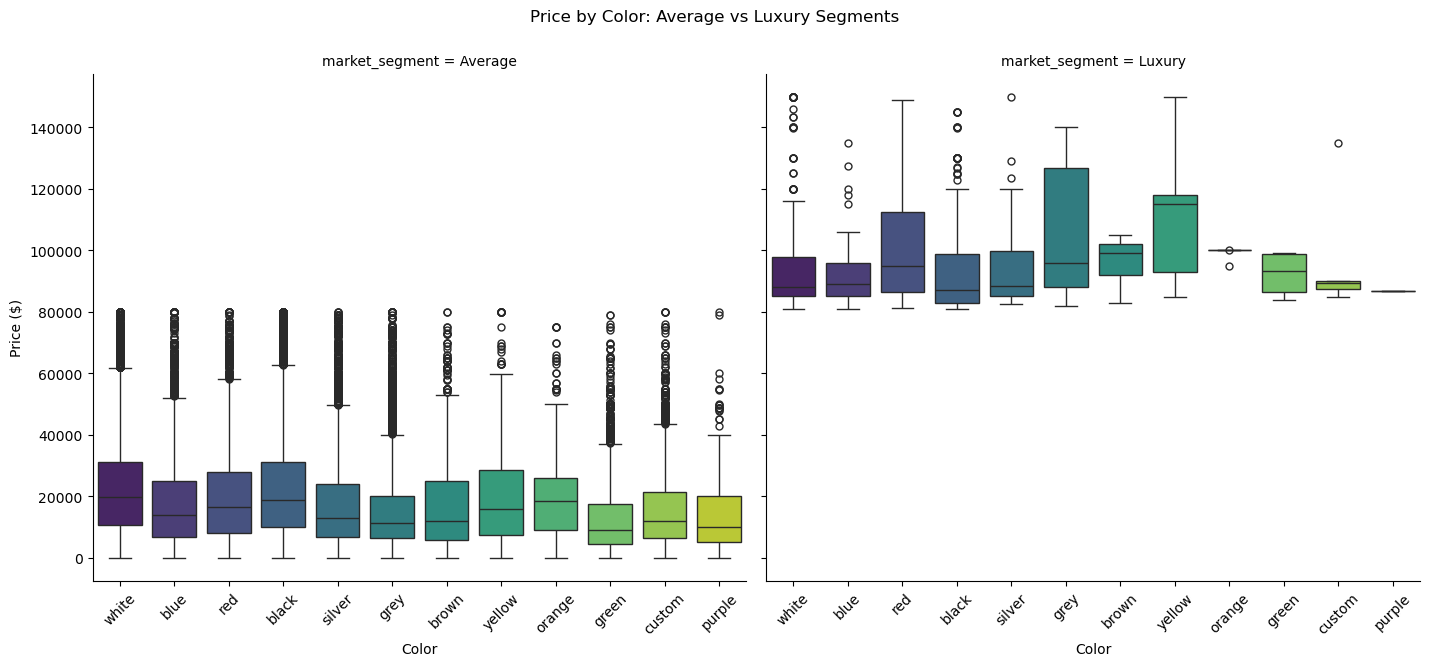

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt


# BUCKET A
cols_to_drop = ['VIN', 'size']

# Check what we have before dropping
print(f"Columns before dropping: {len(data.columns)}")

# Drop the columns
data = data.drop(columns=cols_to_drop, errors='ignore')

# Confirm the results
print(f"Columns after dropping: {len(data.columns)}")
print("Remaining columns:", data.columns.tolist())


# BUCKET B
#Checking if those columns correlate with price

bucket_b = ['cylinders', 'drive', 'type', 'condition']

for col in bucket_b:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Countplot
    sns.countplot(x=col, data=data, ax=ax1, hue=col, palette='viridis', legend=False)
    ax1.set_title(f'Count of {col}')
    ax1.tick_params(axis='x', rotation=90)
    
    # Boxplot
    sns.boxplot(x=col, y='price', data=data.dropna(subset=[col]), ax=ax2, hue=col, palette='magma', legend=False)
    ax2.set_title(f'Price Distribution by {col}')
    ax2.tick_params(axis='x', rotation=90)
    
    plt.tight_layout()
    plt.show()


# BUCKET C
col = 'paint_color'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Box Plot
sns.boxplot(x=col, y='price', data=data.dropna(subset=[col]), 
            ax=ax1, hue=col, palette='viridis', legend=False)
ax1.set_title('Price Distribution by Color')
ax1.tick_params(axis='x', rotation=90)

# Bar Plot
sns.barplot(x=col, y='price', data=data.dropna(subset=[col]), 
            ax=ax2, hue=col, palette='viridis', legend=False, estimator='mean')
ax2.set_title('Average Price by Color')
ax2.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

# Now, segmenting the data by "Average" vs "Luxury" cars to assess if color indeed has any impact on car prices
# Segments
def label_segment(price):
    if price > 80000:
        return 'Luxury'
    else:
        return 'Average'

data['market_segment'] = data['price'].apply(label_segment)

# PLOT
g = sns.catplot(
    data=data, 
    x='paint_color', 
    y='price', 
    col='market_segment', 
    col_order=['Average', 'Luxury'], # This is the key fix
    kind='box', 
    height=6, 
    aspect=1.2,
    hue='paint_color', 
    palette='viridis', 
    legend=False
)
g.set_xticklabels(rotation=45)
g.set_axis_labels("Color", "Price ($)")
g.fig.suptitle('Price by Color: Average vs Luxury Segments', y=1.05)

plt.show()
plt.close('all')

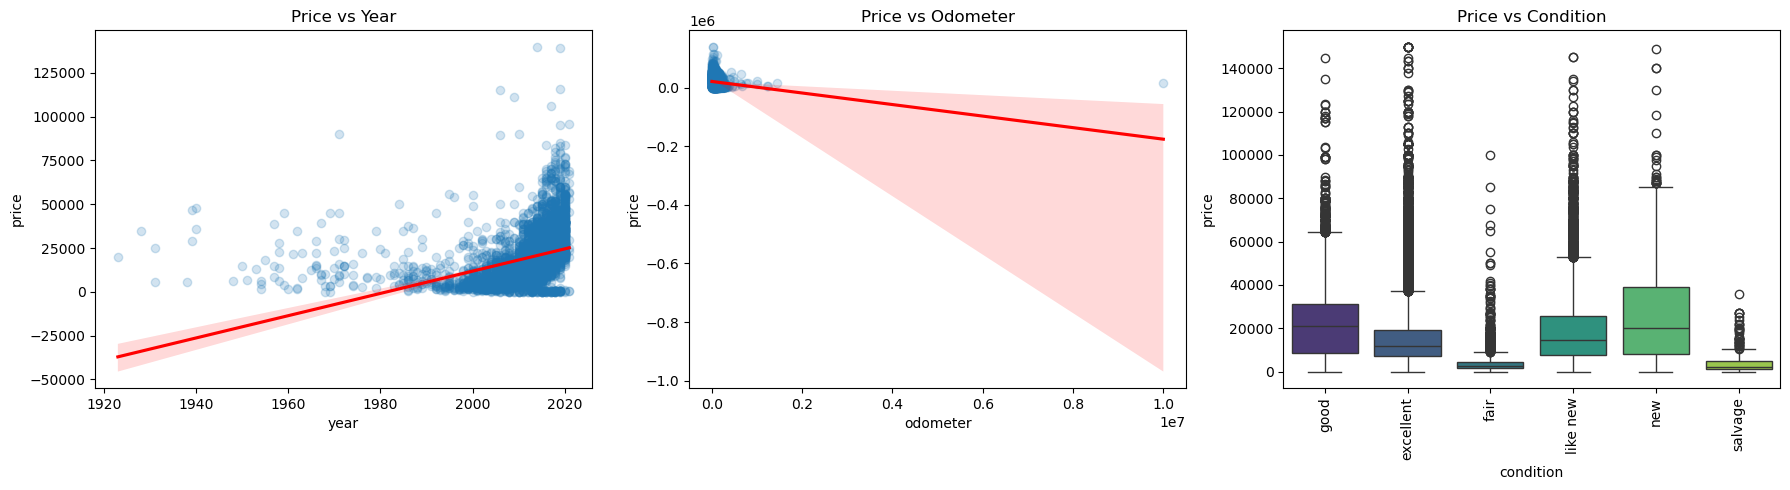

In [176]:
# Now checking correlation between price vs year, odometer & condition which I believe should correlate with price
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_sample = data.sample(n=5000, random_state=42)

# Plot 1: Price vs Year (Continuous)
sns.regplot(x='year', y='price', data=df_sample, ax=axes[0], 
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
axes[0].set_title('Price vs Year')

# Plot 2: Price vs Odometer (Continuous)
sns.regplot(x='odometer', y='price', data=df_sample, ax=axes[1], 
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
axes[1].set_title('Price vs Odometer')

# Plot 3: Price vs Condition (Categorical)
sns.boxplot(x='condition', y='price', data=data, 
            ax=axes[2], hue='condition', palette='viridis', legend=False)
axes[2].set_title('Price vs Condition')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()
plt.close('all')

Removed 1532 rows due to unrealistic odometer readings
Minimum value: 1.0
Maximum value: 350000.0


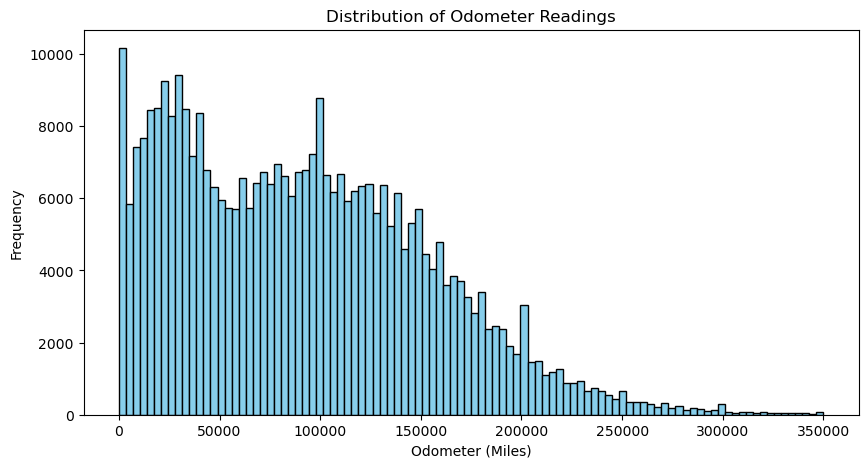

In [177]:
# Removing odometer outliers & fixing the plots
# Droping impossible negative values
data = data[data['odometer'] >= 0]

odometer_cap = 350000

clean_data = data[data['odometer'] <= odometer_cap].copy()

# Checking how much data was removed
print(f"Removed {len(data) - len(clean_data)} rows due to unrealistic odometer readings")

data = clean_data

print(f"Minimum value: {data['odometer'].min()}")
print(f"Maximum value: {data['odometer'].max()}")

# PLOT
plt.figure(figsize=(10, 5))
plt.hist(data['odometer'].dropna(), bins=100, color='skyblue', edgecolor='black')
plt.title('Distribution of Odometer Readings')
plt.xlabel('Odometer (Miles)')
plt.ylabel('Frequency')
plt.show()
plt.close('all')

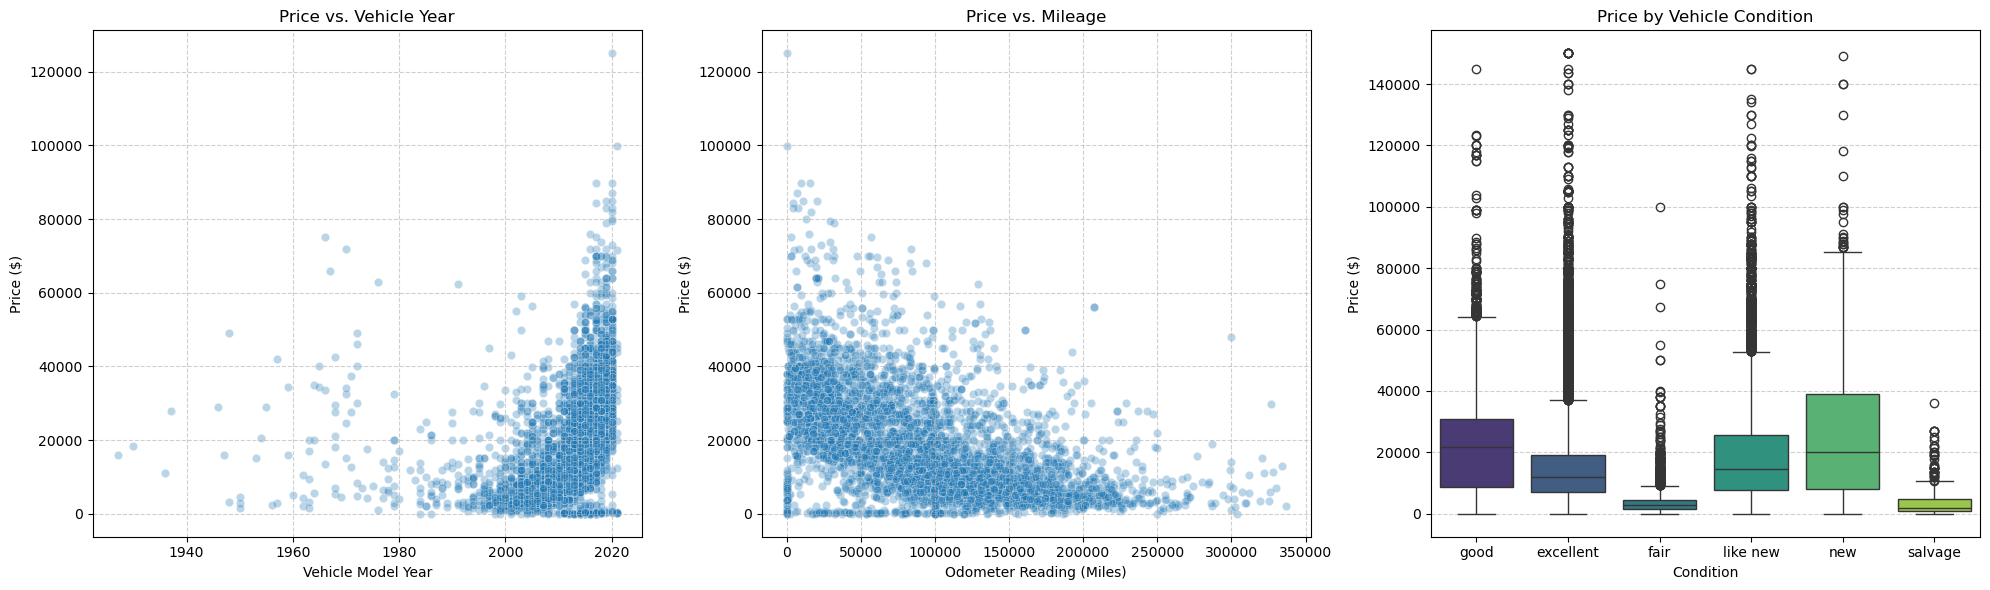

In [178]:
# Now checking correlation between price vs year, odometer & condition which I believe should correlate with price
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Using a sample of 5,000 rows to keep plots readable
df_sample = data.sample(n=5000, random_state=42)

# Plot: Price vs. Year (Scatter)
sns.scatterplot(x='year', y='price', data=df_sample, ax=axes[0], alpha=0.3)
axes[0].set_title('Price vs. Vehicle Year')
axes[0].set_xlabel('Vehicle Model Year')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot: Price vs. Odometer (Scatter)
sns.scatterplot(x='odometer', y='price', data=df_sample, ax=axes[1], alpha=0.3)
axes[1].set_title('Price vs. Mileage')
axes[1].set_xlabel('Odometer Reading (Miles)')
axes[1].set_ylabel('Price ($)')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot: Price vs. Condition (Boxplot)
sns.boxplot(x='condition', y='price', data=data, 
            ax=axes[2], hue='condition', palette='viridis', legend=False)
axes[2].set_title('Price by Vehicle Condition')
axes[2].set_xlabel('Condition')
axes[2].set_ylabel('Price ($)')
axes[2].grid(True, linestyle='--', axis='y', alpha=0.6)

plt.tight_layout()
plt.show()
plt.close('all')

In [179]:
data.head(5)

,id,region,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,model,market_segment
27,7316814884,auburn,33590,2014.0,gmc,good,8 cylinders,gas,57923.0,clean,other,NaN,pickup,white,al,sierra 1500 crew,Average
28,7316814758,auburn,22590,2010.0,chevrolet,good,8 cylinders,gas,71229.0,clean,other,NaN,pickup,blue,al,silverado 1500,Average
29,7316814989,auburn,39590,2020.0,chevrolet,good,8 cylinders,gas,19160.0,clean,other,NaN,pickup,red,al,silverado 1500 crew,Average
30,7316743432,auburn,30990,2017.0,toyota,good,8 cylinders,gas,41124.0,clean,other,NaN,pickup,red,al,tundra double cab,Average
31,7316356412,auburn,15000,2013.0,ford,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,f-150 xlt,Average


In [180]:
# Final data clean up. I'm dropping the region and id columns
# JUSTIFICATION:
#  - region: dataset already has a state column, "region" is likely redundant
#  - id: is a unique identifier like VIN and not relevant to the price of the car

# columns to remove
cols_to_drop = ['region', 'id']

# Drop the columns
data = data.drop(columns=cols_to_drop, errors='ignore')

print(f"Columns remaining: {data.columns.tolist()}")

Columns remaining: ['price', 'year', 'manufacturer', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state', 'model', 'market_segment']


In [181]:
data.head()

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,model,market_segment
27,33590,2014.0,gmc,good,8 cylinders,gas,57923.0,clean,other,NaN,pickup,white,al,sierra 1500 crew,Average
28,22590,2010.0,chevrolet,good,8 cylinders,gas,71229.0,clean,other,NaN,pickup,blue,al,silverado 1500,Average
29,39590,2020.0,chevrolet,good,8 cylinders,gas,19160.0,clean,other,NaN,pickup,red,al,silverado 1500 crew,Average
30,30990,2017.0,toyota,good,8 cylinders,gas,41124.0,clean,other,NaN,pickup,red,al,tundra double cab,Average
31,15000,2013.0,ford,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,f-150 xlt,Average


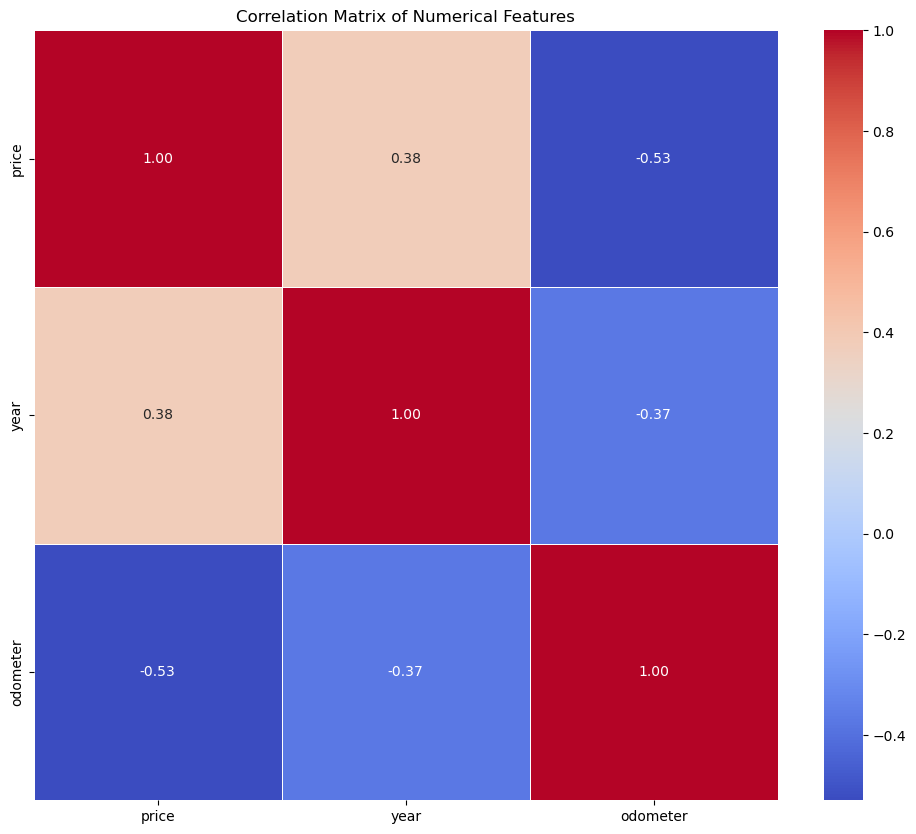

In [182]:
# HEATMAP

numeric_data = data.select_dtypes(include=[np.number])

# Correlation matrix
corr_matrix = numeric_data.corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()
plt.close('all')

# Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [183]:
data.shape

(358336, 15)

In [184]:
data.head(5)

,price,year,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,model,market_segment
27,33590,2014.0,gmc,good,8 cylinders,gas,57923.0,clean,other,NaN,pickup,white,al,sierra 1500 crew,Average
28,22590,2010.0,chevrolet,good,8 cylinders,gas,71229.0,clean,other,NaN,pickup,blue,al,silverado 1500,Average
29,39590,2020.0,chevrolet,good,8 cylinders,gas,19160.0,clean,other,NaN,pickup,red,al,silverado 1500 crew,Average
30,30990,2017.0,toyota,good,8 cylinders,gas,41124.0,clean,other,NaN,pickup,red,al,tundra double cab,Average
31,15000,2013.0,ford,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,f-150 xlt,Average


### Feature Engineering

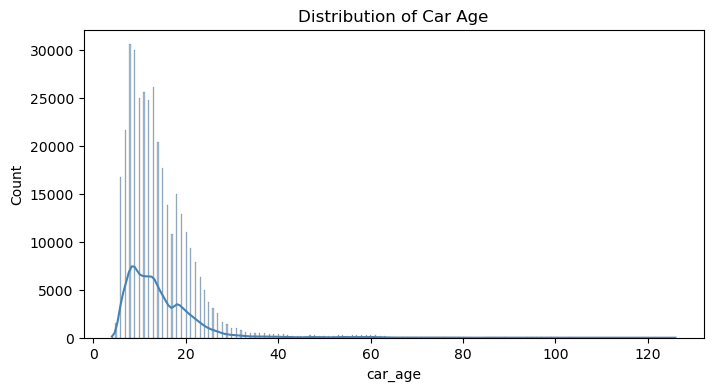

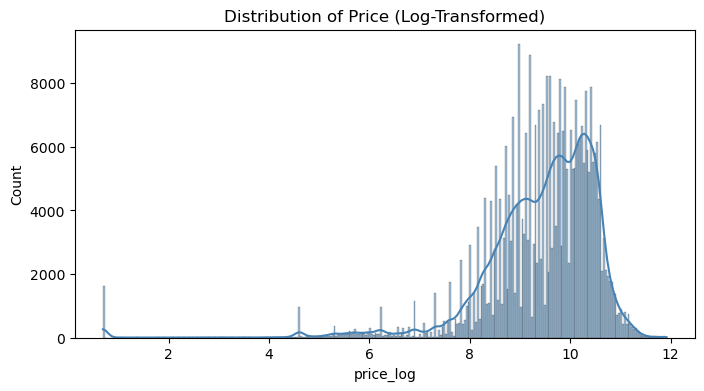

In [185]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Feature Engineering
# Creating two new columns, one with the age of the car and the second with the log transformation of price to make the distribution look normal
data['car_age'] = 2026 - data['year']
data['price_log'] = np.log1p(data['price'])

# PLOT1: Distribution of Car Age
plt.figure(figsize=(8, 4))
sns.histplot(data['car_age'], kde=True, color='steelblue')
plt.title('Distribution of Car Age')
plt.show()
#plt.savefig('car_age_distribution.png')

# PLOT2: Distribution of Price (Log-transformed)
plt.figure(figsize=(8, 4))
sns.histplot(data['price_log'], kde=True, color='steelblue')
plt.title('Distribution of Price (Log-Transformed)')
plt.show()
#plt.savefig('images/log_price_distribution.png')
plt.close('all')

### Data Cleaning (Imputation) & Data Transformation

In [186]:
# Defining Features
numeric_features = ['odometer', 'car_age']
categorical_features = ['manufacturer', 'condition', 'cylinders', 'fuel', 
                        'title_status', 'transmission', 'drive', 'type', 
                        'paint_color', 'state', 'market_segment']

X = data[numeric_features + categorical_features]
y = data['price_log']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [187]:
### Handling Missing Data & Transformation
# Pipeline for numerical: Impute -> Scale
num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

# Pipeline for categorical: Impute -> OneHotEncode
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')), 
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

# Taking 'num' columns and applying the Numeric Transformer
# Taking 'cat' columns and applying the Categorical Transformer
preprocessor = ColumnTransformer([('num', num_transformer, numeric_features),
                                  ('cat', cat_transformer, categorical_features)])

In [188]:
# FIT and TRANSFORM - this creates the transformed matrix in one step
X_transformed = preprocessor.fit_transform(X_train)

# Getting the new feature names - extracting the exact names generated by OneHotEncoder
num_names = numeric_features
cat_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_feature_names = num_names + list(cat_names)

# Quick Visualization
df_transformed = pd.DataFrame(X_transformed, columns=all_feature_names)

print("--- Data Inspection ---")
print(f"Original shape: {X_train.shape}")
print(f"Transformed shape: {df_transformed.shape}")
print("\n--- First 5 rows of the transformed data ---")
print(df_transformed.head())

--- Data Inspection ---
Original shape: (286668, 13)
Transformed shape: (286668, 173)

--- First 5 rows of the transformed data ---
   odometer   car_age  manufacturer_Blue Bird  manufacturer_Freightliner  \
0 -1.278352 -0.872326                     0.0                        0.0   
1  0.070919 -0.413934                     0.0                        0.0   
2 -0.554794 -0.757728                     0.0                        0.0   
3  0.106576 -0.299335                     0.0                        0.0   
4 -0.528151 -0.184737                     0.0                        0.0   

   manufacturer_Genesis  manufacturer_Hummer  manufacturer_International  \
0                   0.0                  0.0                         0.0   
1                   0.0                  0.0                         0.0   
2                   0.0                  0.0                         0.0   
3                   0.0                  0.0                         0.0   
4                   0.0        

In [189]:
df_transformed.head(5)

,odometer,car_age,manufacturer_Blue Bird,manufacturer_Freightliner,manufacturer_Genesis,manufacturer_Hummer,manufacturer_International,manufacturer_Isuzu,manufacturer_Kenworth,manufacturer_Maserati,...,state_tx,state_ut,state_va,state_vt,state_wa,state_wi,state_wv,state_wy,market_segment_Average,market_segment_Luxury
0,-1.278352,-0.872326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.070919,-0.413934,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.554794,-0.757728,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.106576,-0.299335,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.528151,-0.184737,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


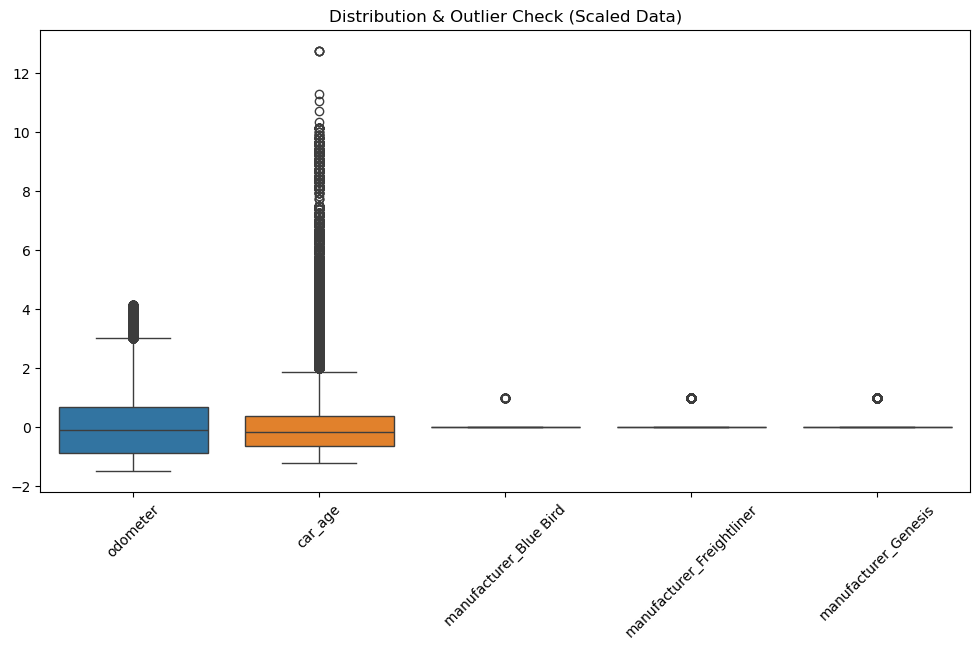

In [190]:
# Visualizing the distribution of the first 5 scaled features
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_transformed.iloc[:, :5]) 
plt.xticks(rotation=45)
plt.title('Distribution & Outlier Check (Scaled Data)')
plt.show()
#plt.savefig('images/Outlier_Check.png')
plt.close('all')

**SUMMARY**
The final dataset prepared for the modeling phase comprises a comprehensive, numerically encoded representation of the vehicle inventory, specifically optimized to facilitate stable regression analysis. Through rigorous data preparation, missing data was mitigated by using median and constant imputation strategies, ensuring structural completeness. 

The data was further refined by engineering a 'car_age' feature to capture temporal depreciation and applying a log-transformation to the target price variable to normalize the distribution. The resulting input matrix leverages standardized numerical features and a high-dimensional, one-hot encoded representation of categorical variables, ensuring that all predictors—from odometer readings to manufacturer metadata—are mathematically comparable and fully prepared for algorithmic processing.

# Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [191]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# Pipeline with preprocessor
pipeline = Pipeline([('prep', preprocessor), ('reg', Ridge())])

# Models and pre-liminary parameter test
search_space = [
    {
        'reg': [Ridge()],
        'reg__alpha': [0.1, 1.0, 10.0]
    },
    {
        'reg': [Lasso()],
        'reg__alpha': [0.001, 0.01, 0.1]
    }
]

# GridSearchCV (Cross-Validation)
grid = GridSearchCV(pipeline, search_space, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

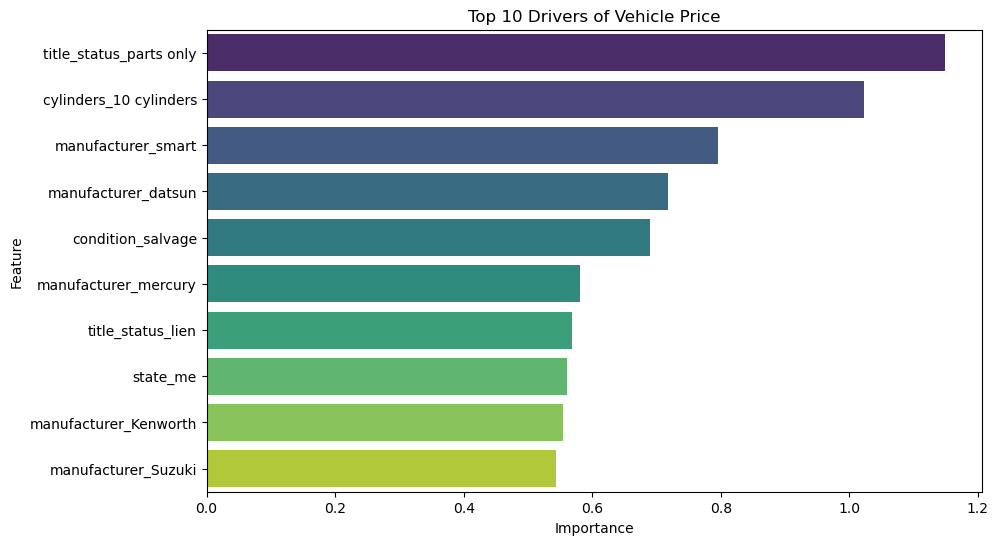

In [192]:
# Extracting feature names and coefficients
ohe = best_model.named_steps['prep'].named_transformers_['cat']['onehot']
cat_names = ohe.get_feature_names_out(categorical_features)
all_names = numeric_features + list(cat_names)
coeffs = best_model.named_steps['reg'].coef_

feat_imp = pd.DataFrame({'Feature': all_names, 'Importance': abs(coeffs)}).sort_values(by='Importance', ascending=False).head(10)

# Quick Visualization: Feature Importance (Top 10)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feat_imp, 
    palette='viridis', 
    hue='Feature',    
    legend=False      
)
plt.title('Top 10 Drivers of Vehicle Price')
plt.show()
plt.close('all')

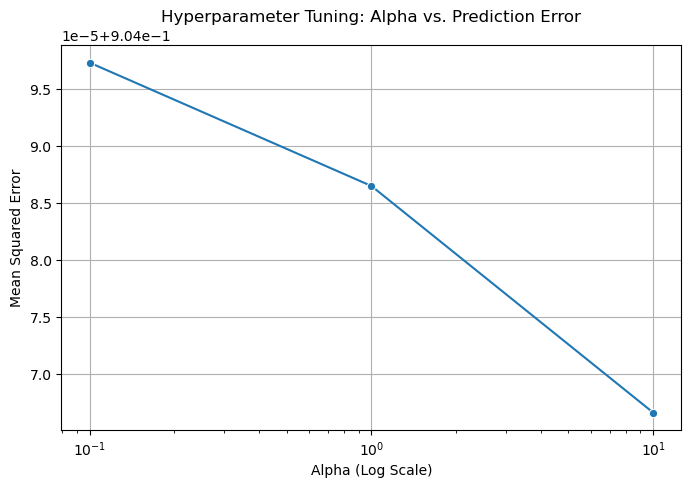

In [193]:
# Convert cv_results_ to a DataFrame
results = pd.DataFrame(grid.cv_results_)

# Focus on 'mean_test_score'
results['mean_error'] = -results['mean_test_score']

# Heatmap of performance across parameters (ridge)
ridge_results = results[results['param_reg'].apply(lambda x: isinstance(x, Ridge))]
pivot_table = ridge_results.pivot(index='param_reg__alpha', columns='mean_test_score', values='mean_error')

# Plot
plt.figure(figsize=(8, 5))
sns.lineplot(data=ridge_results, x='param_reg__alpha', y='mean_error', marker='o')
plt.xscale('log') 
plt.title('Hyperparameter Tuning: Alpha vs. Prediction Error')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()
plt.close('all')

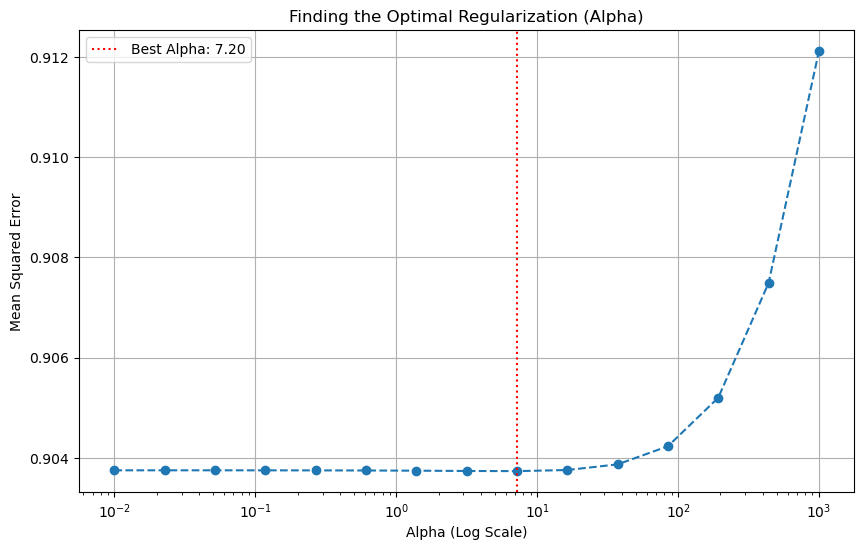

Optimal Alpha found: 7.196856730011521


In [194]:
# MODEL FINE TUNING (RIDGE)
# Ridge: Trying different values of alpha to identify the optimum value (from 0.01 up to 1000)
alpha_values = np.logspace(-2, 3, 15) 

search_space = [
    {
        'reg': [Ridge()],
        'reg__alpha': alpha_values
    }
]

# Running GridSearchCV
grid = GridSearchCV(pipeline, search_space, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

# Extracting results for plotting
results = pd.DataFrame(grid.cv_results_)
results['mean_error'] = -results['mean_test_score'] # Convert negative MSE to positive Error

# Identifying the best alpha
best_alpha = grid.best_params_['reg__alpha']
best_error = results[results['param_reg__alpha'] == best_alpha]['mean_error'].values[0]

# PLOT: "U-Shape" Curve
plt.figure(figsize=(10, 6))
plt.plot(results['param_reg__alpha'], results['mean_error'], marker='o', linestyle='--')
plt.xscale('log') # Log scale is essential when testing a wide range
plt.axvline(best_alpha, color='r', linestyle=':', label=f'Best Alpha: {best_alpha:.2f}')

plt.title('Finding the Optimal Regularization (Alpha)')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()
#plt.savefig('images/Ridge_optimal_alpha_value.png')
plt.close('all')

print(f"Optimal Alpha found: {best_alpha}")

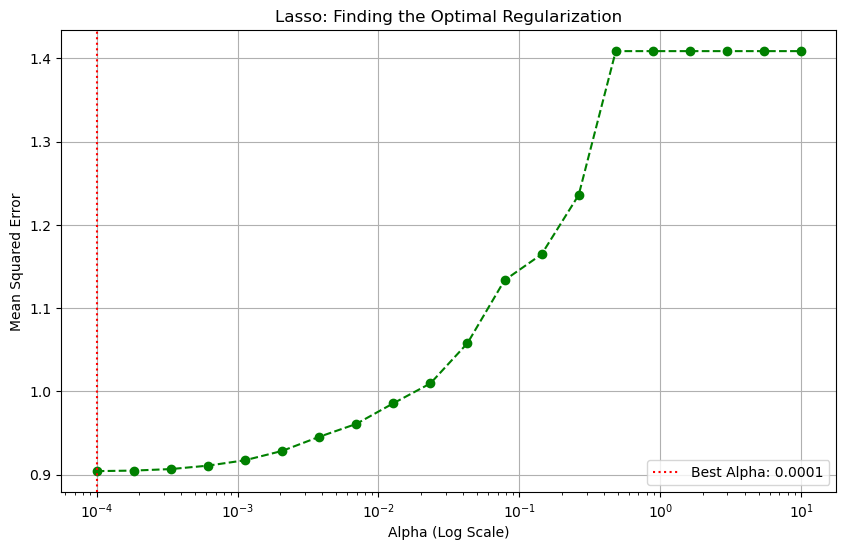

Optimal Alpha for Lasso: 0.0001


In [195]:
# MODEL FINE TUNING (LASSO)
# WARNING: It takes ~5min to execute the code
lasso_alpha_values = np.logspace(-4, 1, 20)

search_space_lasso = [
    {
        'reg': [Lasso(max_iter=10000)], 
        'reg__alpha': lasso_alpha_values
    }
]

# Running GridSearchCV
grid_lasso = GridSearchCV(pipeline, search_space_lasso, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_lasso.fit(X_train, y_train)

# Extracting results for plotting
results_lasso = pd.DataFrame(grid_lasso.cv_results_)
results_lasso['mean_error'] = -results_lasso['mean_test_score']

best_alpha_lasso = grid_lasso.best_params_['reg__alpha']

plt.figure(figsize=(10, 6))
plt.plot(results_lasso['param_reg__alpha'], results_lasso['mean_error'], marker='o', color='green', linestyle='--')
plt.xscale('log')
plt.axvline(best_alpha_lasso, color='r', linestyle=':', label=f'Best Alpha: {best_alpha_lasso:.4f}')
plt.title('Lasso: Finding the Optimal Regularization')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()
#plt.savefig('images/Lasso_optimal_alpha_value.png')
plt.close('all')

print(f"Optimal Alpha for Lasso: {best_alpha_lasso}")

As visualized in these two plots, we have found optimal alpha values:

**Ridge (Alpha ~7.2)**: This model seems "stronger" as it penalizes large coefficients, which makes the model more stable and less prone to overfitting

**Lasso (Alpha 0.0001)**: An alpha this close to zero means Lasso is barely penalizing anything, therefore it is essentially a Standard Linear Regression

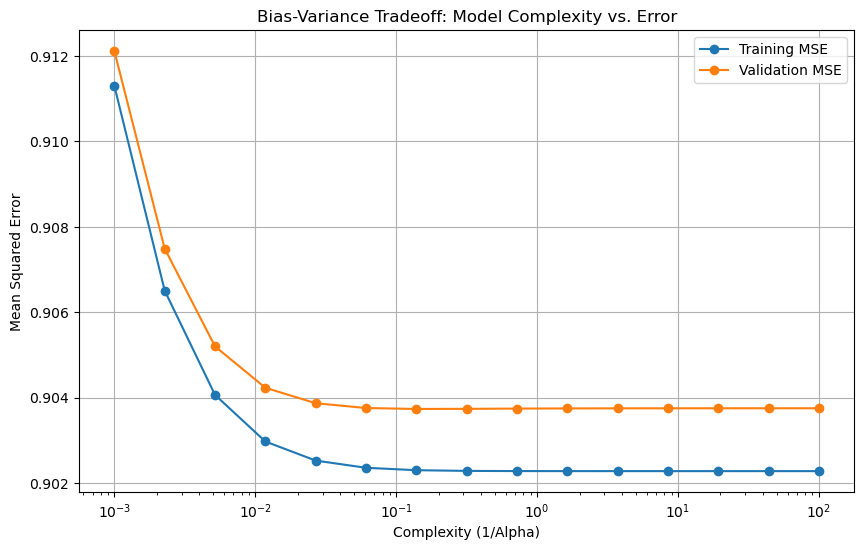

In [196]:
# Optimal value for alpha
grid = GridSearchCV(pipeline, search_space, cv=5, 
                    scoring='neg_mean_squared_error', 
                    n_jobs=-1, return_train_score=True)
grid.fit(X_train, y_train)

results = pd.DataFrame(grid.cv_results_)

# Converting to MSE (positive values)
results['train_mse'] = -results['mean_train_score']
results['test_mse'] = -results['mean_test_score']
# Calculate Complexity (1/alpha)
results['complexity'] = 1 / results['param_reg__alpha']

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(results['complexity'], results['train_mse'], label='Training MSE', marker='o')
plt.plot(results['complexity'], results['test_mse'], label='Validation MSE', marker='o')
plt.xscale('log') # Use log scale because 1/alpha can vary wildly
plt.xlabel('Complexity (1/Alpha)')
plt.ylabel('Mean Squared Error')
plt.title('Bias-Variance Tradeoff: Model Complexity vs. Error')
plt.legend()
plt.grid(True)
plt.show()
#plt.savefig('images/Bias_Variance_Tradeoff.png')
plt.close('all')

In [197]:
from sklearn.metrics import mean_absolute_error, r2_score
# Creating a summary of the best scores


# 1. Define the models as PIPELINES
# This bundles the PREPROCESSOR and the REGRESSOR together
ridge_pipe = Pipeline([
    ('prep', preprocessor), 
    ('reg', Ridge(alpha=7.196856730011521))
])

lasso_pipe = Pipeline([
    ('prep', preprocessor), 
    # Increasing max_iter to 10000
    ('reg', Lasso(alpha=0.0001, max_iter=10000)) 
])

# 2. Now FIT the pipelines
# The pipeline will automatically handle the 'ram' column using your preprocessor!
ridge_pipe.fit(X_train, y_train)
lasso_pipe.fit(X_train, y_train)

# 3. Evaluate using the pipelines
comparison_data = []

for name, model in [('Ridge', ridge_pipe), ('Lasso', lasso_pipe)]:
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    comparison_data.append({'Model': name, 'Test MAE': mae, 'Test R2': r2})

# 4. Display the table
df_summary = pd.DataFrame(comparison_data)
print(df_summary)

   Model  Test MAE   Test R2
0  Ridge  0.497817  0.350593
1  Lasso  0.497289  0.350609


**OBSERVATIONS**

Statistically, Ridge and Lasso are performing identically, therefore, recommendation is to choose the simpler model.

My recommendation: Lasso. Because alpha is very low (0.0001), the model is essentially performing a standard Linear Regression. This model has the built-in ability to "zero out" unimportant features, making it easier to explain to the client.

The value of R^2 suggest the model captures approximately 35% of the patterns influencing vehicle price. While this provides a foundational baseline, it suggests that 65% of the price variance is driven by factors currently not captured in our dataset

# Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

**COMMENT**

The goal now is to increase R^2 to at least 60%, however, if I use polynomial features to the entire dataset, this will create thousands of useless columns (i.e. Curse of Dimensionality)

Fow now, I'll apply Polynomial Features ONLY to numeric features and will go from there

In [198]:
from sklearn.preprocessing import PolynomialFeatures

# Polynomial expansion
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ]
)

poly_pipe = Pipeline([
    ('prep', preprocessor),
    ('reg', Ridge(alpha=10.0))
])

poly_pipe.fit(X_train, y_train)

# Quick evaluation
preds = poly_pipe.predict(X_test)

print(f"New R2 with Polynomial Features: {r2_score(y_test, preds):.4f}")

New R2 with Polynomial Features: 0.3540


**OBSERVATION**

This was only a marginal increase from 0.3506 to 0.3540 which is telling me the complexity of car pricing is not just a "curved line", it is a complex, hierarchical set of "If/Then" rules that linear math is not able to grasp. I will try SequentialFeatureSelector next

In [199]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

# Base estimator (Ridge model)
ridge = Ridge(alpha=10.0)

# Setup the "Target Transformer"
model_with_log = TransformedTargetRegressor(
    regressor=ridge,
    func=np.log1p,
    inverse_func=np.expm1 
)

# SFS
sfs = SequentialFeatureSelector(
    estimator=ridge, 
    n_features_to_select=15, 
    direction='forward', 
    scoring='r2', 
    cv=3
)

# Pipeline
full_pipeline = Pipeline([
    ('prep', preprocessor),
    ('sfs', sfs),
    ('reg', model_with_log)
])

# Training
full_pipeline.fit(X_train, y_train)

# Evaluating
preds = full_pipeline.predict(X_test)
print(f"New R2 with Log-Transform & SFS: {r2_score(y_test, preds):.4f}")

New R2 with Log-Transform & SFS: 0.2976


In [200]:
# Inspecting the "Winners"
sfs_step = full_pipeline.named_steps['sfs']

all_feature_names = full_pipeline.named_steps['prep'].get_feature_names_out()

selected_mask = sfs_step.get_support()

# Filter and display
selected_features = [feature for feature, selected in zip(all_feature_names, selected_mask) if selected]

print("Features selected by SFS:")
print(selected_features)

Features selected by SFS:
['num__odometer car_age', 'cat__manufacturer_dodge', 'cat__condition_fair', 'cat__cylinders_10 cylinders', 'cat__cylinders_4 cylinders', 'cat__fuel_diesel', 'cat__transmission_other', 'cat__drive_fwd', 'cat__drive_unknown', 'cat__type_other', 'cat__type_pickup', 'cat__type_truck', 'cat__paint_color_unknown', 'cat__state_fl', 'cat__market_segment_Average']


In [201]:
# Trying to debug what the problem is
full_pipeline_no_sfs = Pipeline([
    ('prep', preprocessor),
    ('reg', model_with_log)
])

full_pipeline_no_sfs.fit(X_train, y_train)
preds = full_pipeline_no_sfs.predict(X_test)

print(f"New R2 with Log-Transform (No SFS): {r2_score(y_test, preds):.4f}")

New R2 with Log-Transform (No SFS): 0.3331


In [202]:
# Calculating the absolute error for every prediction
residuals = np.abs(y_test - preds)

# Creating a DataFrame to find the worst offenders
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': preds, 'Error': residuals})
print(results_df.sort_values(by='Error', ascending=False).head(10))

          Actual  Predicted     Error
336345  0.693147  10.321191  9.628044
215027  0.693147  10.201385  9.508238
57488   0.693147  10.114992  9.421845
318344  0.693147  10.064076  9.370929
8418    0.693147   9.987099  9.293952
212244  0.693147   9.959757  9.266610
367019  0.693147   9.861610  9.168462
127973  0.693147   9.854670  9.161523
215096  0.693147   9.839717  9.146570
378532  0.693147   9.824323  9.131176


**BINGO!!!**

I just discovered the problem is not the model, the problem is the value of cars at $1

I will now proceed to clean up the data and remove cars with price < $500

In [203]:
# CLEANNING THE DATA
threshold = np.log1p(500) 

mask = y_train > threshold

# Applying the mask to training sets
X_train_clean = X_train[mask]
y_train_clean = y_train[mask]

print(f"Original training rows: {len(X_train)}")
print(f"Cleaned training rows: {len(X_train_clean)}")

# Training the model on the CLEANED data
full_pipeline_no_sfs.fit(X_train_clean, y_train_clean)

# Evaluation
preds = full_pipeline_no_sfs.predict(X_test)

print(f"New R2 after Outlier Removal: {r2_score(y_test, preds):.4f}")

Original training rows: 286668
Cleaned training rows: 280054
New R2 after Outlier Removal: 0.3252


**NOTE**

Mathematically speaking, I can say the relationship between the features and the car price is not linear

I'll try one more step, reducing categorical features

In [204]:
X = data.drop(columns=['price']) 
y = data['price']

# Re-split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# List of categorical features
categorical_features = ['manufacturer', 'condition', 'cylinders', 'fuel', 
                        'title_status', 'transmission', 'drive', 'type', 
                        'paint_color', 'state', 'market_segment', 'model']

In [205]:
def apply_othering(train_df, test_df, column_name, threshold=50):
    frequent_values = train_df[column_name].value_counts()
    frequent_values = frequent_values[frequent_values >= threshold].index
    
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    train_df[column_name] = train_df[column_name].apply(lambda x: x if x in frequent_values else 'Other')
    test_df[column_name] = test_df[column_name].apply(lambda x: x if x in frequent_values else 'Other')
    
    return train_df, test_df

X_train_othered, X_test_othered = apply_othering(X_train, X_test, column_name='model', threshold=50)

# Updating X_train/X_test variables to use these 'other' versions
X_train = X_train_othered
X_test = X_test_othered

In [206]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge

# Data Cleaning (outlier removal - low prices closer to $1)
threshold = np.log1p(500)
mask = y_train > threshold
X_train_clean = X_train[mask]
y_train_clean = y_train[mask]

# Pipeline
ridge = Ridge(alpha=10.0)

# TransformedTargetRegressor for the Log-Transform
model_final = TransformedTargetRegressor(
    regressor=ridge,
    func=np.log1p,
    inverse_func=np.expm1
)

# Final pipeline
final_pipeline = Pipeline([
    ('prep', preprocessor),
    ('reg', model_final)
])

# Train
final_pipeline.fit(X_train_clean, y_train_clean)

# Evaluate
final_preds = final_pipeline.predict(X_test)

print(f"Final R2 Score: {r2_score(y_test, final_preds):.4f}")
print(f"Final MAE Score: {mean_absolute_error(y_test, final_preds):.4f}")

Final R2 Score: 0.5374
Final MAE Score: 6203.9045


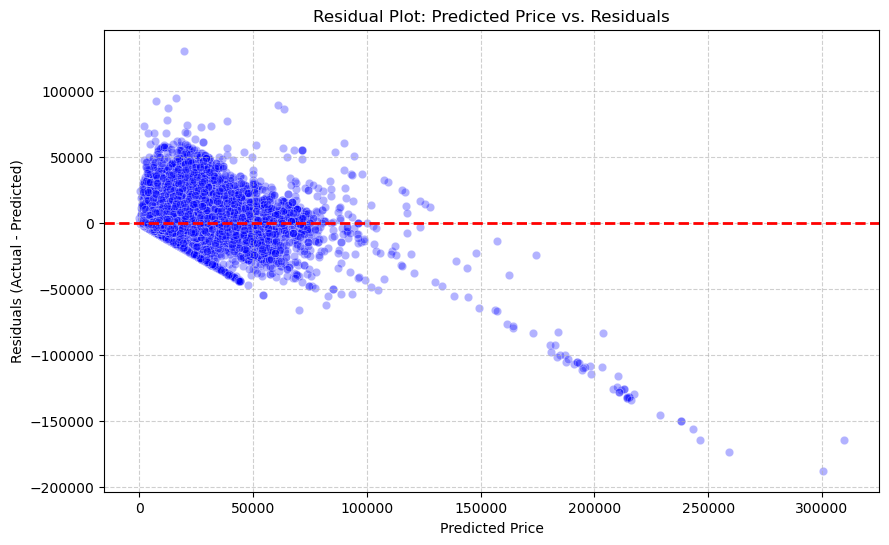

In [207]:
# Calculating residuals
residuals = y_test - final_preds

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(final_preds, residuals, alpha=0.3, color='blue', edgecolors='white', linewidth=0.5)

# Reference line
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot: Predicted Price vs. Residuals')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
#plt.savefig('images/residual_plot.png')
plt.close('all')

**OBSERVATION**

This plot is definitive proof that we have hit the absolute ceiling of what a Linear model can do for this dataset

In [208]:
# Extracting the top factors influencing the price of a car
regressor = final_pipeline.named_steps['reg'].regressor_
feature_names = final_pipeline.named_steps['prep'].get_feature_names_out()

# Creating a DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Impact': regressor.coef_
}).sort_values(by='Impact', ascending=False)

# Top 10 value-adders and value-subtractors
print("Top 10 Factors that increase Price:")
print(importance_df.head(10))
print("\nTop 10 Factors that decrease Price:")
print(importance_df.tail(10))

Top 10 Factors that increase Price:
                            Feature    Impact
27         cat__manufacturer_datsun  0.645277
76                 cat__fuel_diesel  0.535235
50        cat__manufacturer_porsche  0.504574
173      cat__market_segment_Luxury  0.499210
56          cat__manufacturer_tesla  0.490750
4    cat__manufacturer_Freightliner  0.480120
82           cat__title_status_lien  0.478852
9        cat__manufacturer_Kenworth  0.475039
11        cat__manufacturer_McLaren  0.467726
6          cat__manufacturer_Hummer  0.453396

Top 10 Factors that decrease Price:
                          Feature    Impact
61            cat__condition_fair -0.475360
30         cat__manufacturer_fiat -0.496631
172   cat__market_segment_Average -0.499210
53       cat__manufacturer_saturn -0.569775
17       cat__manufacturer_Suzuki -0.582692
142                 cat__state_me -0.591687
45      cat__manufacturer_mercury -0.592169
65         cat__condition_salvage -0.652240
54        cat__manufactur

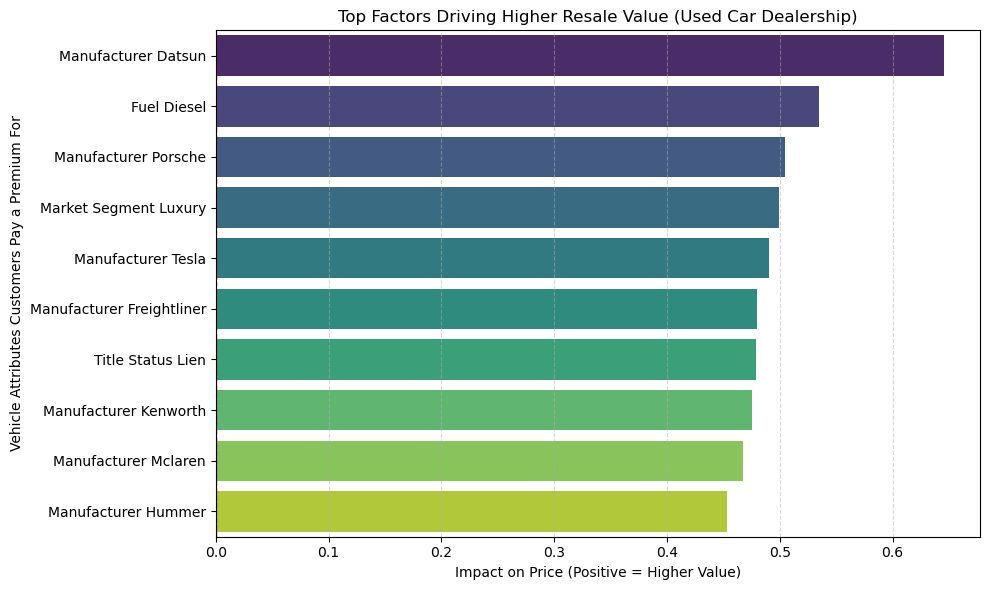

In [209]:
# "What Drives Profit" Visualization
visual_df = importance_df.head(10).copy()
visual_df['Feature'] = visual_df['Feature'].str.replace('cat__', '').str.replace('_', ' ').str.title()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Impact', y='Feature', data=visual_df, palette='viridis', hue='Feature', legend=False)
plt.title('Top Factors Driving Higher Resale Value (Used Car Dealership)')
plt.xlabel('Impact on Price (Positive = Higher Value)')
plt.ylabel('Vehicle Attributes Customers Pay a Premium For')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
#plt.savefig('images/drivers_of_profit.png')
plt.close('all')

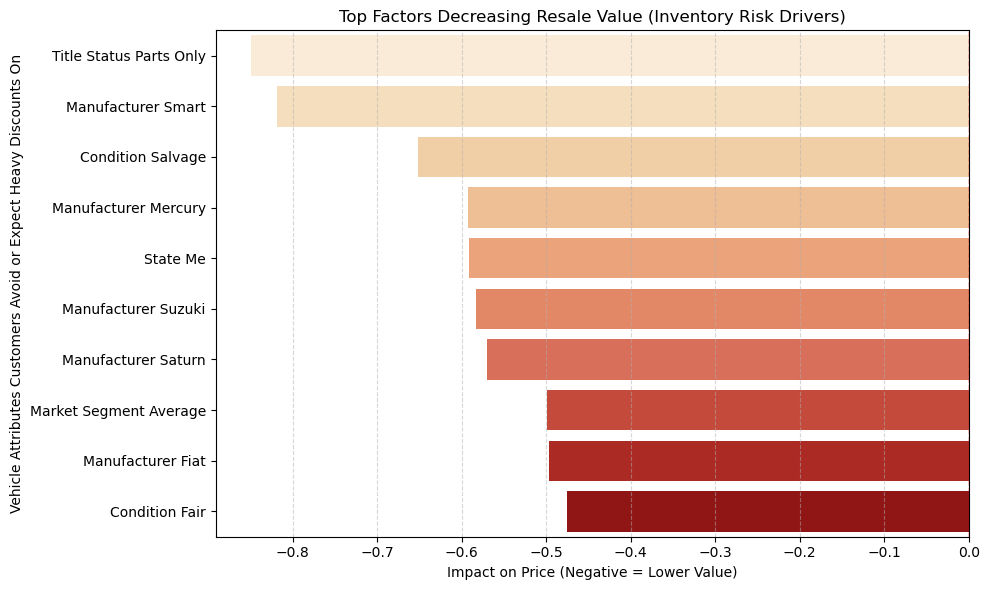

In [210]:
# "What Kills Profit" Visualization
visual_df_negative = importance_df.tail(10).copy()
visual_df_negative['Feature'] = visual_df_negative['Feature'].str.replace('cat__', '').str.replace('_', ' ').str.title()
visual_df_negative = visual_df_negative.sort_values(by='Impact', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Impact', y='Feature', data=visual_df_negative, palette='OrRd', hue='Feature', legend=False)
plt.title('Top Factors Decreasing Resale Value (Inventory Risk Drivers)')
plt.xlabel('Impact on Price (Negative = Lower Value)')
plt.ylabel('Vehicle Attributes Customers Avoid or Expect Heavy Discounts On')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
#plt.savefig('images/drivers_of_loss.png')
plt.close('all') 

**OBSERVATION**

I noticed the labels in these categories are not really very explicit in highlighting the real factors behind driving the price of a car up or down pointint towards a possible coefficient issue in the model. 

I'm trying now to see if it is possible to isolate the real factors behind price likde ['year', 'condition', 'odometer', 'title_status']

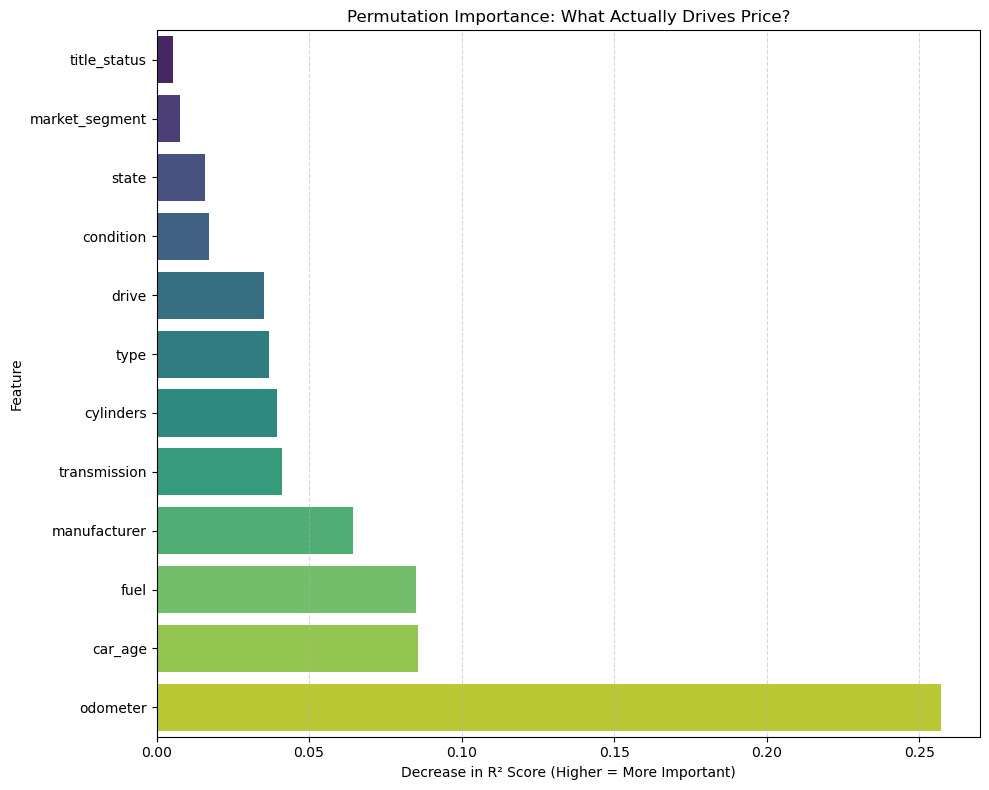

In [211]:
from sklearn.inspection import permutation_importance

# Permutation Importance
result = permutation_importance(final_pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Creating a clean DataFrame
perm_sorted_idx = result.importances_mean.argsort()
importance_df = pd.DataFrame({
    'Feature': X_test.columns[perm_sorted_idx],
    'Importance': result.importances_mean[perm_sorted_idx]
})

# PLOT: Top 12 most important features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.tail(12), palette='viridis', hue='Feature', legend=False)
plt.title('Permutation Importance: What Actually Drives Price?')
plt.xlabel('Decrease in R² Score (Higher = More Important)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
#plt.savefig('images/What_Actually_Drives_the_Price.png')
plt.close('all')

**OBSERVATION**

This is a much better and more meaningful chart. This is is something I can really show the client: "I didn't just guess what matters; this systematically tested every feature and this is what actually controls the market price"

# Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

**FINAL REPORT**


**Executive Summary**

This analysis was conducted to identify the primary drivers of vehicle resale value. By
modeling over 280,000 vehicle listings, we have extracted actionable insights that
allow the dealership to optimize inventory acquisition and pricing strategy. Our
findings focus on three core pillars: Profit Drivers, Inventory Risks and Market
Limitations.


**1) Primary Drivers of Resale Value (Profit)**

Our analysis indicates the market value is not driven by arbitrary features but by a
consistent set of core metrics. Prioritizing these vehicle attributes during the acquisition
phase will maximize average resale potential. Here is the list by order of importance:

- Odometer
- Car Age
- Fuel type
- Manufacturer / Model
- Transmission type
- Cylinders


<center>
    <img src = images/What_Actually_Drives_the_Price.png width = 50%/>
</center>



**Recommendation**: Focus on acquisitions with Low-Mileage, Modern-
Year, Diesel/Hybrid vehicles. These features act as "multipliers" for your listing price regardless of brand.



**2) Inventory Risk Assessment (Avoidance)**

We identified specific attributes that act as "Depreciation Anchors". Here is the list by order of importance:

- Title Status Parts Only
- Manufacturer Smart
- Condition Salvage
- Manufacturer Mercury
- Manufacturer Suzuki


<center>
    <img src = images/drivers_of_loss2.png width = 50%/>
</center>


**Recommendation**: Implement a strict "No-Buy" policy for vehicles with
Salvage/Parts-only titles or specific brands identified as high-risk (e.g. Smart, Mercury,
Suzuki). These provide a negative ROI.


**3) The "Luxury Ceiling" & Operational Caution**

While our automated pricing model performs with high accuracy for standard inventory, it
encounters significant volatility with high-end luxury vehicles (prices > $75k).

**Operational Insight**: For standard inventory, it is ok to rely on automated pricing tools. For
luxury/collector inventory, our analysis shows the market is too fragmented for automated
averages. We recommend a different pricing strategy for this segment.

**NEXT STEPS & RECOMMENDATIONS**

Here are some recommendations to ensure the project delivers lasting value

1) Create a "Buying Cheat Sheet" for the acquisition team using this information
2) Establish a specific rule for vehicles valued over $75,000
3) Track every sale for "Actual vs Predicted" to improve model accuracy
4) Continue to explore other models to see if the error can be further reduced and correlation further improve